# Dell Kit End Date Prediction
**Zakir Patwa · Data Science Case Study · 2026**

**Goal:** predict `kit_end`, the date kitting finishes, for each of the 12,069 orders in `inference.parquet` (kit starts Feb 3 – Mar 7, 2026), using 179,853 historical orders (kit starts Mar 2025 – Jan 2026).

**Deliverables:** this notebook, `README.md` (findings + recommendations), and `Zakir_Patwa_DS_Case_Predictions_2026.npy` (one predicted date per inference row, same order).

**Outline**
1. Problem framing and key decisions
2. Assumptions log (kept up to date as each cleaning/join decision is made)
3. Load data
4. Exploration, organized around three hypotheses: supply constraints, human schedules, warehouse congestion
5. Cleaning
6. Feature engineering
7. Modeling: baselines, classifier vs. regressor, metrics, probability checks, error analysis
8. Inference predictions

## 1. Problem framing and key decisions

Six decisions shape everything downstream. Each one lists the choice, the alternative considered, and the reason.

**1. Target: predict duration in calendar days, not a date.**
`kit_days = kit_end − kit_start`. The model predicts `kit_days`, and the date is rebuilt as `kit_end = kit_start + kit_days`. `kit_start` is known for every inference order, so duration is the only unknown, and duration patterns carry over across months where raw dates never repeat. *Alternative:* business days using the calendar table. Rejected because weekend work is routine (~35k kits start on a Saturday even though the calendar marks Saturday as a weekend), and the calendar only runs through 2026-03-10, barely covering the inference window. Historical median is 1 day, mean 1.34.

**2. Model: build a classifier and a regressor, keep the better one.**
- *Classifier:* LightGBM on five buckets {0, 1, 2, 3, 4+}. Over 94% of orders take 0–3 days (0d 19.5% · 1d 48.4% · 2d 17.0% · 3d 9.1% · 4d+ ~6%), so the buckets cover the practical decision space, and rare 20–76 day outliers can't distort the fit. A "4+" prediction maps to the training median of 4+ orders. It also gives a **probability per bucket**, which powers a high-risk flag for orders likely to run long.
- *Regressor:* LightGBM predicting `kit_days` directly, rounded to whole days.
- *Selection:* whichever scores higher on validation **±1-day accuracy**. LightGBM (gradient-boosted decision trees) is the standard for tabular data: it handles categorical columns and missing values natively and trains in seconds.

**3. Validation: time-based split, not random.**
Train on `kit_start` ≤ 2025-11-30 (146,444 rows) and validate on Dec 2025 – Jan 2026 (33,409 rows, 19%). Inference is entirely in the future (Feb–Mar 2026), so validation has to be too. A random split would let the model learn from Dec 15 to "predict" Dec 14, which inflates scores. Note that validation is *harder* than inference is likely to be: it contains the Dec 23–27, Jan 1 and Jan 15 holidays (0-day kits 14.7% vs 19.5% overall; 4+ 8.4% vs ~6%), and there are no holidays in Feb–Mar. Validation scores are therefore a conservative estimate. After model selection, the final model is retrained on all data through Jan 31.

**4. Baselines: the model must beat three simple rules.**
All medians are computed from training data only.
1. *Always 1 day*: the most common outcome (48%).
2. *Median `kit_days` per `family_desc`*: a rule a planner could run in a spreadsheet.
3. *Median per `family_desc` × `mcid` (warehouse)*: falls back to the family median when a family–warehouse combination has fewer than 30 training orders, and to the global median for families never seen in training.

If the model can't clearly beat baseline 3, its extra complexity isn't justified.

**5. Metrics.**
- **Within ±1 day % (primary)**: close enough for a planner to schedule around.
- **Exact-day %**, **MAE** (average days off), **macro-F1** (does it get the rare buckets right, not just "1 day"?), and a **confusion matrix** (which mistakes it makes).
- **Probability checks** for the risk flag: **log loss** (penalizes confident wrong answers), a **calibration chart** (among orders given a 30% risk, do ~30% actually run long?), and flag **precision/recall** (are the alarms real, and do they catch the slow orders?). The flag is a claim to planners, so it has to be tested, not just produced.

**6. Output format.**
`Zakir_Patwa_DS_Case_Predictions_2026.npy` holds `datetime64[D]` dates (day precision, loads with a plain `np.load`). Before saving, the notebook asserts: length 12,069, no missing dates, no `kit_end` before `kit_start`, and row order identical to `inference.parquet`. A supporting CSV (`Zakir_Patwa_DS_Case_Predictions_2026.csv`: order ID, family, kit start, predicted kit end, predicted days, risk probability) is produced for planners to open in Excel.

## 2. Assumptions log
*Updated as each cleaning, join, or modeling decision is made.*

**Problem setup**
- A1. `kit_start` is known at prediction time for every inference order (it is provided in `inference.parquet`), so predicting duration is legitimate and not leakage.
- A2. Calendar days are the right unit (see Decision 1); weekends are not treated as non-working days.
- A3. Kitting behavior in Feb–Mar 2026 resembles Mar 2025 – Jan 2026 closely enough for historical patterns to apply. No holidays fall in the inference window.

**Reference tables**
- A4. The calendar table is tagged site `FCJ`, but every order is site `KHO`. Assumed to be one factory, so the calendar is joined on date only.
- A5. Calendar `day_of_week` is encoded 1 = Saturday, 2 = Sunday (per the data dictionary).

**Modeling**
- A6. A "4+ days" prediction is converted to a date using the training median of 4+ orders.
- A7. Families never seen in training (2 families, 10 inference rows) get the global median in the baselines. The model handles them through parent family and other features.
- A8. All medians, encodings and fallbacks are fit on training rows only, so validation stays honest.

**Exploration findings that shape cleaning and features**
- A9. The extract appears filtered on `kit_end` ≥ 2025-03-10 (the earliest `kit_end` in the file). Orders that started before 2025-03-10 are a biased, slow-only sample and are excluded from exploration and training (1,392 rows).
- A10. Same-day order volume is not used as a model feature: inference averages 431 orders/day vs 626 in training, so the inference file may not contain the full daily workload.

**Cleaning (section 5)**
- A11. The 734 negative-`kit_days` rows have a re-stamped `kit_start` (712 sit on three dates). The true start is unrecoverable, so they are dropped from training. Inference may contain similar re-stamped starts that can't be detected.
- A12. The 10 repeated (`sales_order_id`, `family_desc`) keys are kept: each pair differs in `tie_num` and `line_qty`, so they are separate sub-lines.
- A13. `order_amt` = 0 and `est_ship_date` = 1900-01-01 are treated as missing (not real values) and flagged.
- A14. The regressor trains on `kit_days` capped at the training-period 99th percentile (5 days, 1.09% of rows). Evaluation always uses true `kit_days`.
- A15. `capacity` has one distinct set of values per date; duplicates are exact copies and are dropped.

**Features (section 6)**
- A16. A date with no row in `capacity` (inside its date range) is a non-working day; dates after 2026-03-07 are unknown (left missing). This flags a closure on 2026-02-06/07 inside the inference window.
- A17. Target encodings use smoothing weight m = 30 and 5-fold out-of-fold values on the fitting rows; the regression-style encodings use capped `kit_days`.
- A18. Calendar month is excluded: training has no February, so a month feature would extrapolate blindly.
- A19. Overtime and regular hours on the start date are treated as known in advance (a staffing plan).

**Modeling (section 7)**
- A20. `est_ship_date` is assumed to be set before kitting starts (it is provided for inference orders). If it is revised after kitting, `ship_slack_days` would leak the outcome.
- A21. When the two models' ±1-day accuracies are statistically indistinguishable (bootstrap over kit-start days), the lower-MAE model is selected.
- A22. The risk flag threshold targets the riskiest ~10% of orders (set on November, P(4+) ≥ 0.096), a workload a planning team could review.
- A23. The final models reuse the tree counts chosen by early stopping on the inner split.

**Predictions (section 8)**
- A24. The risk-flag threshold (0.096) is kept fixed at inference, which flags 19.4% of orders because the retrained classifier's risk level is higher; ranking by risk is the recommended way to pick a smaller review list.

## 3. Load data

Five tables, all read from `Data/` (not committed to the repo):

| Table | Grain | Role |
|---|---|---|
| `train` | one row per order line, with `kit_end` | learn from |
| `inference` | same columns, minus `kit_end` | predict; **row order must be preserved** |
| `expected_minutes` | one row per product family | engineered labor-time estimate per unit |
| `calendar` | one row per date | weekends, holidays, end-of-quarter flags |
| `capacity` | one row per date (after dedupe) | overtime hours |

The shape checks below catch a wrong or truncated file before any analysis starts.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)

DATA_DIR = Path("Data")

train = pd.read_parquet(DATA_DIR / "train.parquet")
inference = pd.read_parquet(DATA_DIR / "inference.parquet")
expected_minutes = pd.read_parquet(DATA_DIR / "expected_minutes.parquet")
calendar = pd.read_parquet(DATA_DIR / "calendar.parquet")
capacity = pd.read_parquet(DATA_DIR / "capacity.parquet")

tables = {
    "train": train,
    "inference": inference,
    "expected_minutes": expected_minutes,
    "calendar": calendar,
    "capacity": capacity,
}
for name, df in tables.items():
    print(f"{name:<17} {df.shape[0]:>8,} rows x {df.shape[1]:>2} cols")

# Guard against a wrong or truncated file
assert train.shape == (179_853, 19)
assert inference.shape == (12_069, 18)

# Inference has every train column except the target
print("\nIn train but not inference:", sorted(set(train.columns) - set(inference.columns)))

train              179,853 rows x 19 cols
inference           12,069 rows x 18 cols
expected_minutes       260 rows x  4 cols
calendar               370 rows x 17 cols
capacity           191,934 rows x  4 cols

In train but not inference: ['kit_end']


## 4. Exploration

**Framing.** From a supply-chain view, kitting (gathering every part an order needs) should be fast when three things hold and slow when any one breaks:

| Hypothesis | Mechanism | What the data can measure (proxy) |
|---|---|---|
| **H1. Supply constraints** | One short part (e.g. a constrained CPU) holds up the whole unit | `kit_days` by product family; the same family over time (shortage periods); wait between `download_date` and `kit_start` |
| **H2. Human schedules** | Weekends, holidays and overtime decide when people are on the floor | `kit_days` by start weekday; holiday weeks; overtime hours from `capacity` |
| **H3. Warehouse space / congestion** | A crowded warehouse slows picking and staging | `kit_days` by warehouse (`mcid`); number of orders starting the same day |

**Important gap:** the data has **no direct measure of part availability or warehouse space**. H1 and H3 can only be tested through proxies, so each verdict below is marked *supported*, *not supported*, or *can't tell*, with the numbers behind it.

Note: text fields (family names, business lines) are obfuscated in the source data, so charts show codes rather than product names.

In [2]:
import matplotlib.pyplot as plt

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    """Save a chart to figures/ (used by the README) and show it."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


# One chart style for the whole notebook: quiet axes and gridlines, one color set
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
})

# Target: calendar days from kit start to kit end (Decision 1)
train["kit_days"] = (train["kit_end"] - train["kit_start"]).dt.days

print(train["kit_days"].describe().round(2).to_string())
print(f"\nNegative (kit_end before kit_start): {(train['kit_days'] < 0).sum():,} rows")

count    179853.00
mean          1.34
std           1.63
min         -25.00
25%           1.00
50%           1.00
75%           2.00
max          76.00

Negative (kit_end before kit_start): 734 rows


### 4.1 What does the target look like?
Before testing causes, check the shape of `kit_days` itself: where most orders land and how long the slow tail is. Extremes are grouped into "<0" and "10+" so the handful of very long orders don't hide the main bars.

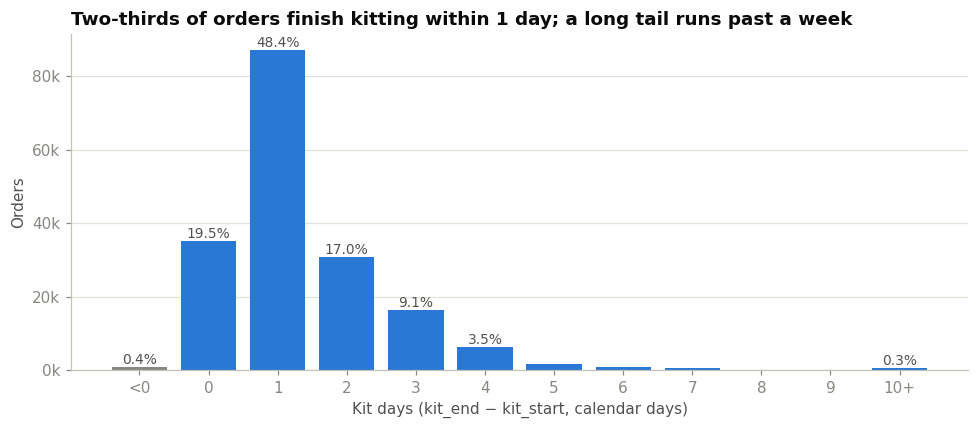

0–1 days: 67.9% · 0–3 days: 94.1% · 4+ days: 5.5% · 10+ days: 475 orders


In [3]:
days = train["kit_days"]
labels = ["<0"] + [str(d) for d in range(10)] + ["10+"]
counts = [(days < 0).sum()] + [(days == d).sum() for d in range(10)] + [(days >= 10).sum()]
shares = np.array(counts) / len(days)

fig, ax = plt.subplots()
colors = [MUTED] + [BLUE] * 11          # negatives are data errors, shown in gray
ax.bar(labels, counts, color=colors, width=0.8)
for i, (c, s) in enumerate(zip(counts, shares)):
    if s >= 0.01 or labels[i] in ("<0", "10+"):   # label the meaningful bars only
        ax.text(i, c, f"{s:.1%}", ha="center", va="bottom", fontsize=9, color=INK_2)
ax.set_title("Two-thirds of orders finish kitting within 1 day; a long tail runs past a week")
ax.set_xlabel("Kit days (kit_end − kit_start, calendar days)")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
plt.tight_layout()
save_fig(fig, "c1_kit_days_distribution")

print(f"0–1 days: {(days.between(0, 1)).mean():.1%} · 0–3 days: {(days.between(0, 3)).mean():.1%} · "
      f"4+ days: {(days >= 4).mean():.1%} · 10+ days: {(days >= 10).sum():,} orders")

**Takeaways**
- **Right-skewed with a long tail.** 67.9% of orders finish in 0–1 days and 94.1% within 3 days, but 5.5% take 4+ days and 475 orders take 10+ (max 76). The average (1.34) is pulled up by that tail, so the median (1) is the better "typical" value.
- **"1 day" alone is right 48.4% of the time.** That is the floor any model must beat (Baseline 1).
- **The tail is where the business pain is.** A 1-day order predicted as 2 is a minor miss; a 15-day order predicted as 1 is a missed ship date. The hypotheses below look for what drives the tail.
- **734 rows (0.4%) have `kit_end` before `kit_start`.** This is impossible, so they are data errors, investigated and handled in Cleaning.

### 4.2 H1: Supply constraints

No column records part availability, so H1 is tested with three proxies:
1. **Do some product families kit much slower than others?** Families share parts, so a family that is consistently slow points to a hard-to-get part.
2. **Do families have bursts of slow weeks that the rest of the plant doesn't?** A shortage is temporary and product-specific, so it should look like one family slowing down while the plant runs normally.
3. **Does waiting longer before kitting starts change kitting time?** If orders wait because parts are missing, a long wait might go with a long kit.

The charts below leave out two groups of rows, both handled in Cleaning: the 734 rows with negative `kit_days`, and orders that started before 2025-03-10. The earliest `kit_end` in the file is 2025-03-10, so the extract appears to be filtered on `kit_end`. Orders that started Mar 4–9 were only included if they ran long (78–100% of Mar 6–7 starts are slow), which would make early March look like a crisis that didn't happen. An order counts as **slow** when it takes 4+ days (5.5% of orders).

Exploration rows: 177,727 of 179,853


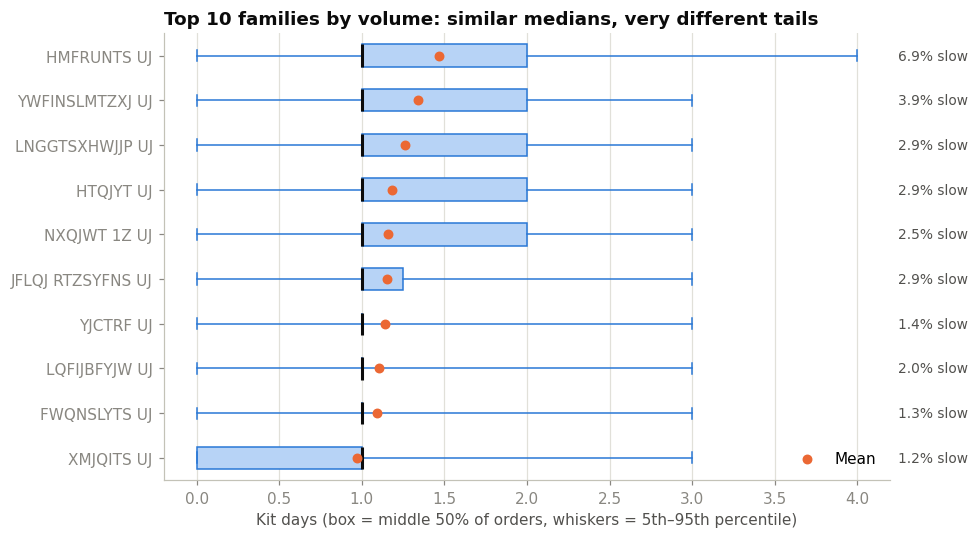

Families with 200+ orders: 113
  mean kit days ranges 0.73 → 4.44
  share of slow (4+) orders ranges 0.0% → 66.5%


In [4]:
# Two row groups are left out of exploration; both are handled in Cleaning (section 5):
#   negative kit_days (data errors) and kit starts before 2025-03-10 (extract-window artifact)
EDA_START = pd.Timestamp("2025-03-10")
eda = train[(train["kit_days"] >= 0) & (train["kit_start"] >= EDA_START)].copy()
print(f"Exploration rows: {len(eda):,} of {len(train):,}")
eda["slow"] = eda["kit_days"] >= 4

top10 = eda["family_desc"].value_counts().head(10).index
fam_stats = (eda[eda["family_desc"].isin(top10)]
             .groupby("family_desc")["kit_days"]
             .agg(orders="size", mean="mean", median="median", slow_share=lambda s: (s >= 4).mean())
             .sort_values("mean"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([eda.loc[eda["family_desc"] == f, "kit_days"] for f in fam_stats.index],
           vert=False, tick_labels=fam_stats.index, whis=(5, 95), showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#b7d3f6", edgecolor=BLUE), medianprops=dict(color=INK, linewidth=2),
           whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
ax.scatter(fam_stats["mean"], range(1, 11), color=ORANGE, s=30, zorder=3, label="Mean")
for y, share in enumerate(fam_stats["slow_share"], start=1):
    ax.annotate(f"{share:.1%} slow", xy=(1.01, y), xycoords=("axes fraction", "data"),
                va="center", fontsize=9, color=INK_2)
ax.grid(axis="x", color=GRID)
ax.grid(axis="y", visible=False)
ax.set_title("Top 10 families by volume: similar medians, very different tails")
ax.set_xlabel("Kit days (box = middle 50% of orders, whiskers = 5th–95th percentile)")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
save_fig(fig, "h1_top10_families")

# Same comparison across every family with enough orders to trust its average
fam_all = eda.groupby("family_desc").agg(orders=("kit_days", "size"), mean=("kit_days", "mean"),
                                         slow_share=("slow", "mean"))
fam_all = fam_all[fam_all["orders"] >= 200]
print(f"Families with 200+ orders: {len(fam_all)}")
print(f"  mean kit days ranges {fam_all['mean'].min():.2f} → {fam_all['mean'].max():.2f}")
print(f"  share of slow (4+) orders ranges {fam_all['slow_share'].min():.1%} → {fam_all['slow_share'].max():.1%}")

**Reading the chart.** Each row is one product family. The box covers the middle half of its orders, the black line is the median, and the orange dot is the mean. When the dot sits to the right of the median line, a few very slow orders are pulling the average up. Nearly every family has a median of 1 day, so the families differ mainly in how often they have a **slow tail** (the percentages on the right).

Next: is that tail constant, or does it come in bursts? The heatmap shows, week by week, the share of slow orders for the 12 highest-volume families, with the plant-wide rate as the top row. How to read it:
- a **vertical stripe** (every family slow in the same week) means a plant-wide cause, such as a holiday (H2)
- an **isolated dark cell** (one family slow while the rest of the plant is fine) is what a part shortage would look like (H1)

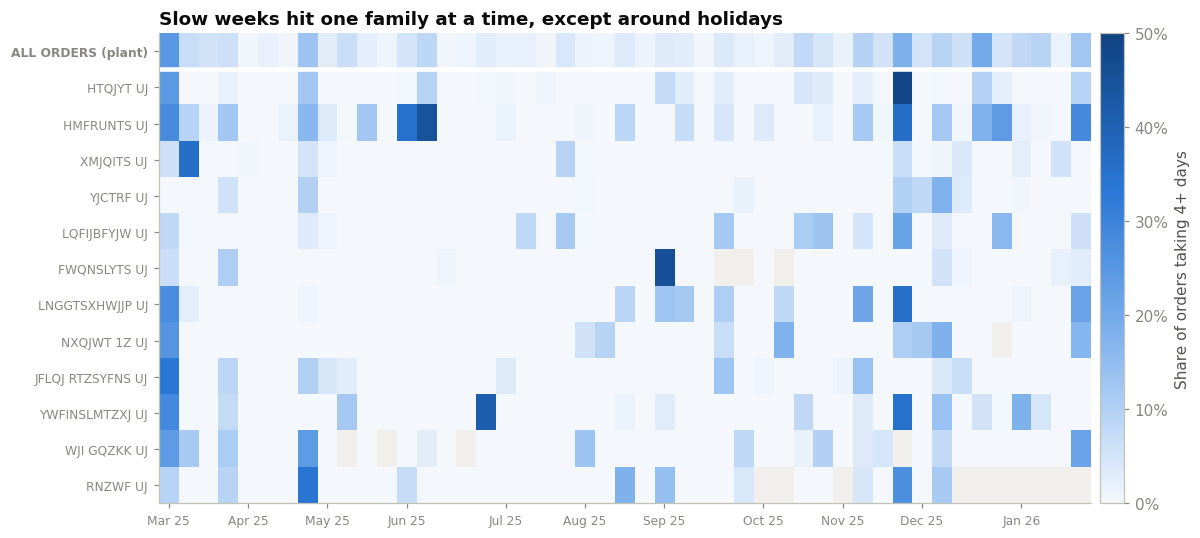

Family-weeks with 20+ orders: 1,928
'Burst' family-weeks (family slow share > plant share that week + 25 pts): 83 (4.3%)
Share of ALL slow orders that fall inside those bursts: 31.0%

Largest bursts:
             family_desc       week  orders  slow_share  excess
          XUNYEJW JC500W 2025-06-30      21        1.00    0.97
              PJJHMN IXX 2025-11-17      20        0.95    0.90
                HFSJD UJ 2025-04-14      23        0.87    0.85
   JFLQJ RTZSYFNS AXFSWS 2025-12-01      39        0.87    0.82
YMZSIJW AFQQJD-RJ5024 UA 2026-01-05      33        0.88    0.80


In [5]:
from matplotlib.colors import LinearSegmentedColormap

eda["week"] = eda["kit_start"].dt.to_period("W").dt.start_time
plant_week = eda.groupby("week")["slow"].mean()

fam_week = (eda.groupby(["family_desc", "week"])["slow"]
            .agg(orders="size", slow_share="mean").reset_index())
fam_week = fam_week[fam_week["orders"] >= 20]            # ignore thin weeks
fam_week["excess"] = fam_week["slow_share"] - fam_week["week"].map(plant_week)

top12 = eda["family_desc"].value_counts().head(12).index
grid = (fam_week[fam_week["family_desc"].isin(top12)]
        .pivot(index="family_desc", columns="week", values="slow_share")
        .reindex(index=top12, columns=plant_week.index))
grid = pd.concat([plant_week.to_frame("ALL ORDERS (plant)").T, grid])

blues = LinearSegmentedColormap.from_list("blues", ["#f4f8fd", "#86b6ef", "#2a78d6", "#104281"])
blues.set_bad("#f0efec")                                  # gray = fewer than 20 orders that week
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(grid.values, aspect="auto", cmap=blues, vmin=0, vmax=0.5, interpolation="nearest")
ax.set_yticks(range(len(grid)))
ax.set_yticklabels(grid.index, fontsize=8)
ax.get_yticklabels()[0].set_fontweight("bold")
month_starts = [i for i, w in enumerate(grid.columns) if i == 0 or w.month != grid.columns[i - 1].month]
ax.set_xticks(month_starts)
ax.set_xticklabels([grid.columns[i].strftime("%b %y") for i in month_starts], fontsize=8)
ax.axhline(0.5, color="white", linewidth=3)
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cbar.set_label("Share of orders taking 4+ days", color=INK_2)
cbar.ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Slow weeks hit one family at a time, except around holidays")
plt.tight_layout()
save_fig(fig, "h1_family_week_heatmap")

bursts = fam_week[fam_week["excess"] > 0.25]
slow_in_bursts = (bursts["orders"] * bursts["slow_share"]).sum()
print(f"Family-weeks with 20+ orders: {len(fam_week):,}")
print(f"'Burst' family-weeks (family slow share > plant share that week + 25 pts): {len(bursts)} "
      f"({len(bursts) / len(fam_week):.1%})")
print(f"Share of ALL slow orders that fall inside those bursts: {slow_in_bursts / eda['slow'].sum():.1%}")
print("\nLargest bursts:")
print(bursts.sort_values("excess", ascending=False).head(5)
      .assign(week=lambda d: d["week"].dt.date).round(2).to_string(index=False))

**Proxy 3: waiting time.** `wait_days = kit_start − download_date` is how long an order sat between entering the factory system and kitting starting. If orders wait because parts haven't arrived, long waits might go with slow kits.

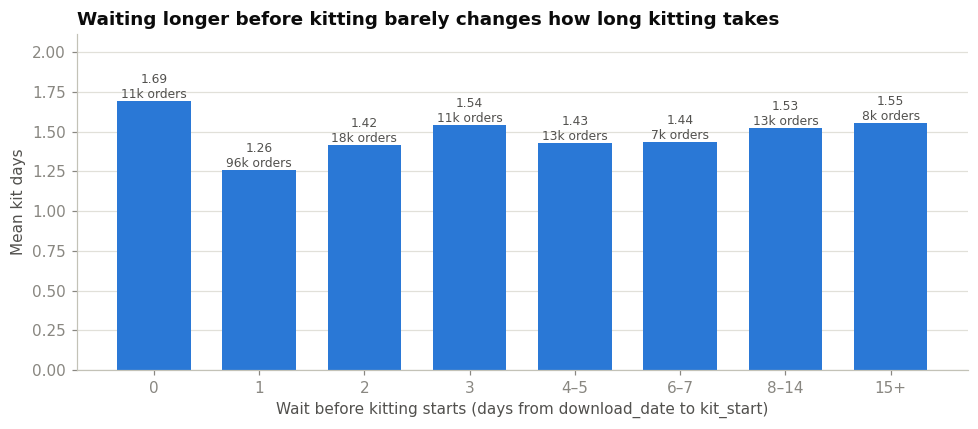

             orders  mean_kit_days  slow_share
wait_bucket                                   
0             10737          1.690       0.079
1             96149          1.258       0.045
2             17971          1.416       0.055
3             11135          1.539       0.055
4–5           13278          1.431       0.042
6–7            7461          1.437       0.082
8–14          12682          1.525       0.072
15+            8309          1.553       0.067

Rank correlation (Spearman) between wait and kit days: 0.034  (0 = no relationship, 1 = perfect)


Missing download_date (wait unknown): 5 rows


In [6]:
eda["wait_days"] = (eda["kit_start"] - eda["download_date"]).dt.days
wait_bins = [-1, 0, 1, 2, 3, 5, 7, 14, np.inf]
wait_labels = ["0", "1", "2", "3", "4–5", "6–7", "8–14", "15+"]
eda["wait_bucket"] = pd.cut(eda["wait_days"], wait_bins, labels=wait_labels)
wait_stats = eda.groupby("wait_bucket", observed=True).agg(
    orders=("kit_days", "size"), mean_kit_days=("kit_days", "mean"), slow_share=("slow", "mean"))

fig, ax = plt.subplots()
ax.bar(wait_stats.index.astype(str), wait_stats["mean_kit_days"], color=BLUE, width=0.7)
for i, (m, n) in enumerate(zip(wait_stats["mean_kit_days"], wait_stats["orders"])):
    ax.text(i, m, f"{m:.2f}\n{n/1000:.0f}k orders", ha="center", va="bottom", fontsize=8, color=INK_2)
ax.set_ylim(0, wait_stats["mean_kit_days"].max() * 1.25)
ax.set_title("Waiting longer before kitting barely changes how long kitting takes")
ax.set_xlabel("Wait before kitting starts (days from download_date to kit_start)")
ax.set_ylabel("Mean kit days")
plt.tight_layout()
save_fig(fig, "h1_wait_vs_kit_days")

rho = eda[["wait_days", "kit_days"]].corr(method="spearman").iloc[0, 1]
print(wait_stats.round(3).to_string())
print(f"\nRank correlation (Spearman) between wait and kit days: {rho:.3f}  (0 = no relationship, 1 = perfect)")
print(f"Missing download_date (wait unknown): {eda['download_date'].isna().sum()} rows")

**H1 verdict: supported (indirectly), and the strongest signal in the data.**
- **Families differ a lot in their slow tail.** Among the 113 families with 200+ orders, mean kit time ranges from 0.73 to 4.44 days, and the share of slow orders ranges from 0% to 66.5%. In the top 10 alone, the slow share ranges from 1.1% to 7.1%.
- **Slowdowns come in family-specific bursts.** 83 family-weeks (4.3% of family-weeks with 20+ orders) have a slow share at least 25 points above the plant's that same week. Those bursts hold **31.0% of all slow orders**. A temporary, product-specific slowdown while the rest of the plant runs normally is what a part shortage looks like.
- **Waiting time is not a useful signal.** The Spearman correlation is 0.03. Orders kitted the same day they download are slightly slower (1.69 mean days), possibly rush orders started before all parts were staged.
- **Limit:** this is circumstantial. Without part-availability data, a family burst could also be an engineering change, a quality hold, or a process issue. The model can learn *which families* tend to be slow, but it **cannot see a new shortage coming**. That is the case for recording part availability (see recommendations).

### 4.3 H2: Human schedules

Three proxies:
1. **Start weekday.** The plant rarely works Sundays (only 1,301 orders ever start on one), so an order started on Saturday that needs a second day loses Sunday.
2. **Holidays.** Does a holiday inside the kitting window (the start day or the next 3 days) slow orders down?
3. **Overtime.** The `capacity` table records overtime hours per day. Do overtime days kit faster?

`capacity` has 191,934 rows but only 317 distinct dates (each date is repeated, plus 12 rows with no date). It is reduced to one row per date here, and properly in Cleaning.

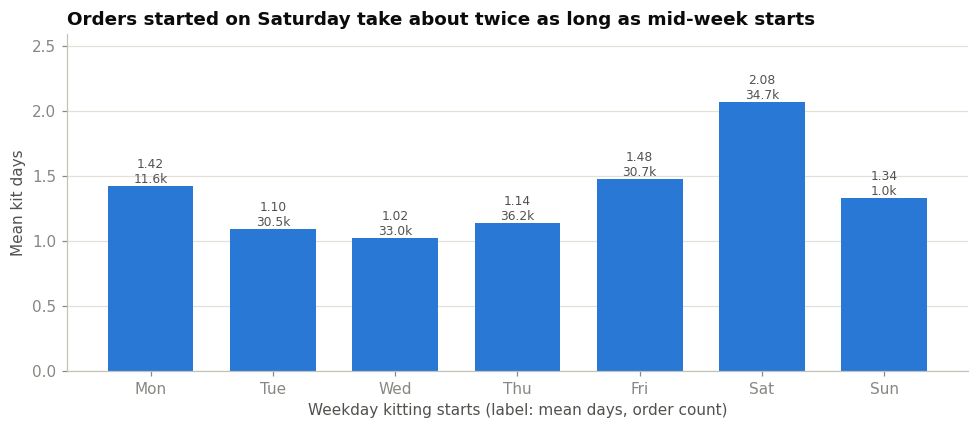

               orders  mean_kit_days  median  slow_share  vs_family_avg
start_weekday                                                          
Monday          11556          1.423     1.0       0.029         -0.012
Tuesday         30548          1.096     1.0       0.043         -0.267
Wednesday       32987          1.022     1.0       0.021         -0.328
Thursday        36188          1.137     1.0       0.054         -0.209
Friday          30672          1.479     1.0       0.087          0.103
Saturday        34727          2.076     2.0       0.069          0.678
Sunday           1049          1.337     1.0       0.046         -0.020

vs_family_avg = mean days above/below the order's own family average, i.e. the weekday effect with product mix removed


In [7]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
eda["start_weekday"] = pd.Categorical(eda["kit_start"].dt.day_name(), weekday_order, ordered=True)
eda["family_adj_days"] = eda["kit_days"] - eda.groupby("family_desc")["kit_days"].transform("mean")
dow_stats = eda.groupby("start_weekday", observed=True).agg(
    orders=("kit_days", "size"), mean_kit_days=("kit_days", "mean"), median=("kit_days", "median"),
    slow_share=("slow", "mean"), vs_family_avg=("family_adj_days", "mean"))

fig, ax = plt.subplots()
ax.bar([d[:3] for d in dow_stats.index], dow_stats["mean_kit_days"], color=BLUE, width=0.7)
for i, (m, n) in enumerate(zip(dow_stats["mean_kit_days"], dow_stats["orders"])):
    ax.text(i, m, f"{m:.2f}\n{n/1000:.1f}k", ha="center", va="bottom", fontsize=8, color=INK_2)
ax.set_ylim(0, dow_stats["mean_kit_days"].max() * 1.25)
ax.set_title("Orders started on Saturday take about twice as long as mid-week starts")
ax.set_xlabel("Weekday kitting starts (label: mean days, order count)")
ax.set_ylabel("Mean kit days")
plt.tight_layout()
save_fig(fig, "h2_weekday")
print(dow_stats.round(3).to_string())
print("\nvs_family_avg = mean days above/below the order's own family average, i.e. the weekday effect with product mix removed")

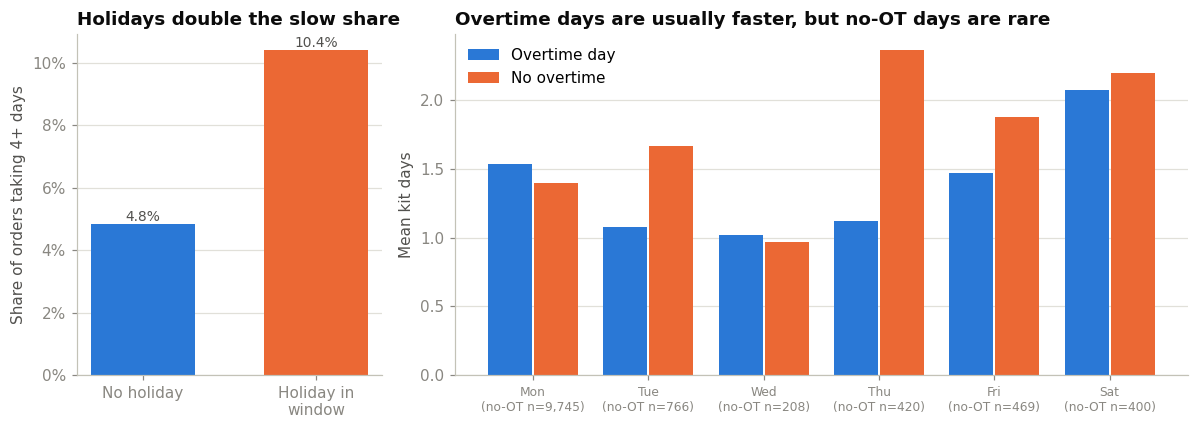

                   orders  mean_kit_days  slow_share
holiday_in_window                                   
False              163074          1.345       0.048
True                14653          1.660       0.104

Days with overtime: 83% of 317 capacity dates
               size         mean      
ot_flag           0      1     0     1
start_weekday                         
Monday         9745   1811  1.40  1.54
Tuesday         766  29782  1.67  1.08
Wednesday       208  32779  0.97  1.02
Thursday        420  35768  2.36  1.12
Friday          469  30203  1.88  1.47
Saturday        400  34327  2.20  2.07


In [8]:
cap_daily = capacity.dropna(subset=["date"]).drop_duplicates("date")
holidays = set(calendar.loc[calendar["is_holiday"] == 1, "date"])
eda["holiday_in_window"] = eda["kit_start"].apply(
    lambda d: any(d + pd.Timedelta(days=k) in holidays for k in range(4)))
eda = eda.merge(cap_daily[["date", "ot_flag", "ot_hours"]], left_on="kit_start", right_on="date",
                how="left").drop(columns="date")

hol_stats = eda.groupby("holiday_in_window").agg(
    orders=("kit_days", "size"), mean_kit_days=("kit_days", "mean"), slow_share=("slow", "mean"))
ot_stats = (eda[eda["start_weekday"] != "Sunday"]
            .groupby(["start_weekday", "ot_flag"], observed=True)["kit_days"]
            .agg(["size", "mean"]).unstack("ot_flag"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 2.4]})
ax1.bar(["No holiday", "Holiday in\nwindow"], hol_stats["slow_share"], color=[BLUE, ORANGE], width=0.6)
for i, s in enumerate(hol_stats["slow_share"]):
    ax1.text(i, s, f"{s:.1%}", ha="center", va="bottom", fontsize=9, color=INK_2)
ax1.set_title("Holidays double the slow share")
ax1.set_ylabel("Share of orders taking 4+ days")
ax1.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

x = np.arange(len(ot_stats))
ax2.bar(x - 0.2, ot_stats[("mean", 1)], width=0.38, color=BLUE, label="Overtime day")
ax2.bar(x + 0.2, ot_stats[("mean", 0)], width=0.38, color=ORANGE, label="No overtime")
ax2.set_xticks(x)
ax2.set_xticklabels([f"{d[:3]}\n(no-OT n={int(n):,})" for d, n in zip(ot_stats.index, ot_stats[("size", 0)])],
                    fontsize=8)
ax2.set_title("Overtime days are usually faster, but no-OT days are rare")
ax2.set_ylabel("Mean kit days")
ax2.legend(frameon=False)
plt.tight_layout()
save_fig(fig, "h2_holiday_overtime")

print(hol_stats.round(3).to_string())
print(f"\nDays with overtime: {cap_daily['ot_flag'].mean():.0%} of {len(cap_daily)} capacity dates")
print(ot_stats.round(2).to_string())

**H2 verdict: supported for weekdays and holidays; overtime is suggestive but can't be separated cleanly.**
- **Weekday is a strong, consistent effect.** Saturday starts average **2.08 days** (median 2) against 1.02 on Wednesday. With product mix removed, Saturday starts still run +0.68 days over their family's average, and Wednesday starts run −0.33. Friday is second slowest (1.48) because it also runs into the weekend. This is mostly arithmetic: in calendar days, a job that crosses a non-working Sunday takes longer.
- **Holidays matter.** When a holiday falls on the start day or within the next 3 days, the slow share roughly doubles (**10.4% vs 4.8%**) and the mean rises from 1.35 to 1.66 days.
- **Overtime: can't tell.** 83% of days have overtime, so no-overtime days are rare and mostly Mondays. On the few no-overtime Tuesdays, Thursdays and Fridays, kitting is slower (e.g. Thursday 2.36 vs 1.12). That fits "overtime helps", but those days are few (208–766 orders) and may be unusual days for other reasons.
- **Implication for inference:** Feb–Mar 2026 has **no holidays**, so the holiday effect won't apply there. Weekday and overtime still will, so both become model features.

### 4.4 H3: Warehouse space and congestion

Two proxies (there is no direct measure of space or occupancy):
1. **Warehouse (`mcid`).** Are some warehouses slower? Warehouses stock different products, so each is compared with **product mix removed**: each order's kit days minus its family's average, averaged per warehouse. A warehouse at +0.5 kits the *same* products half a day slower than elsewhere.
2. **Daily volume.** On days when many orders start kitting, are more of them slow?

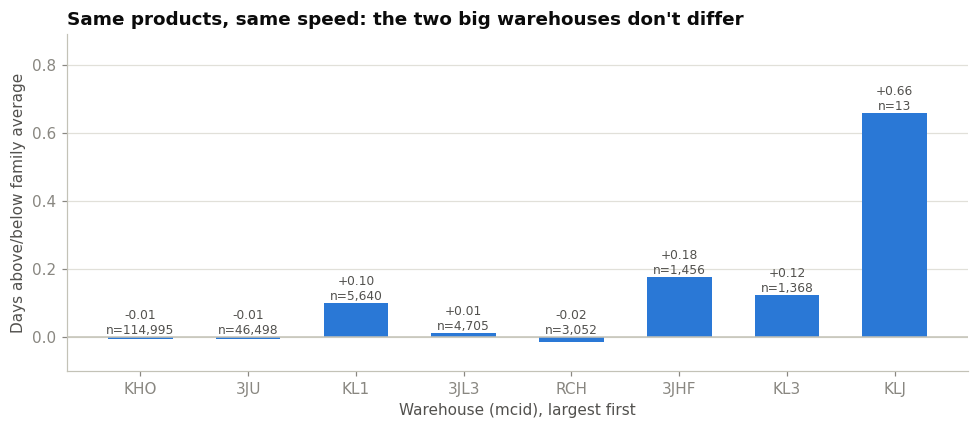

      orders  mean_kit_days  slow_share  vs_family_avg
mcid                                                  
KHO   114995          1.282       0.040         -0.006
3JU    46498          1.575       0.085         -0.006
KL1     5640          1.427       0.061          0.099
3JL3    4705          1.341       0.034          0.013
RCH     3052          1.240       0.029         -0.016
3JHF    1456          1.747       0.115          0.176
KL3     1368          1.617       0.078          0.123
KLJ       13          2.154       0.231          0.659


In [9]:
wh_stats = (eda.groupby("mcid")
            .agg(orders=("kit_days", "size"), mean_kit_days=("kit_days", "mean"),
                 slow_share=("slow", "mean"), vs_family_avg=("family_adj_days", "mean"))
            .sort_values("orders", ascending=False))

fig, ax = plt.subplots()
ax.bar(wh_stats.index, wh_stats["vs_family_avg"], color=BLUE, width=0.6)
ax.axhline(0, color="#c3c2b7", linewidth=1)
for i, (v, n) in enumerate(zip(wh_stats["vs_family_avg"], wh_stats["orders"])):
    ax.text(i, max(v, 0), f"{v:+.2f}\nn={n:,}", ha="center", va="bottom", fontsize=8, color=INK_2)
ax.set_ylim(min(wh_stats["vs_family_avg"].min() * 1.3, -0.1), wh_stats["vs_family_avg"].max() * 1.35)
ax.set_title("Same products, same speed: the two big warehouses don't differ")
ax.set_xlabel("Warehouse (mcid), largest first")
ax.set_ylabel("Days above/below family average")
plt.tight_layout()
save_fig(fig, "h3_warehouse")
print(wh_stats.round(3).to_string())

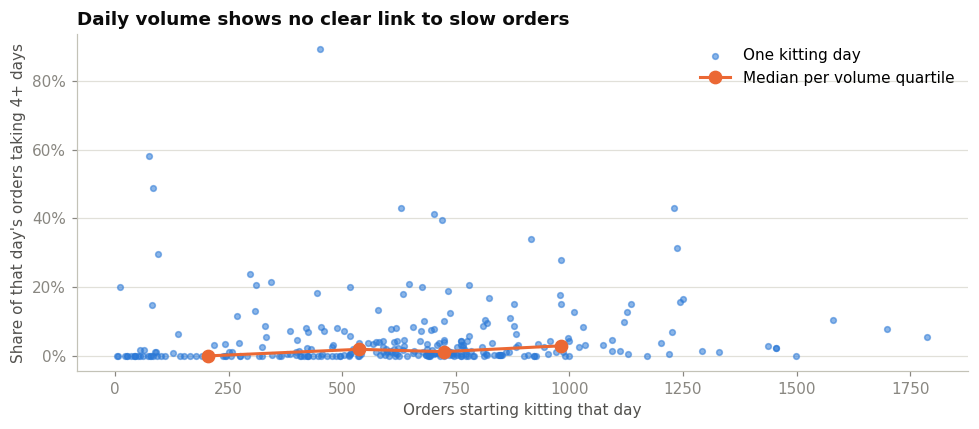

                 days  median_orders  median_slow_share  mean_slow_share
volume_quartile                                                         
Q1 (quietest)      71          205.0              0.000            0.045
Q2                 71          537.0              0.019            0.052
Q3                 71          723.0              0.012            0.041
Q4 (busiest)       71          981.0              0.029            0.063

Spearman: volume vs mean kit days 0.07; volume vs slow share 0.27
Train: 626 orders/day on 284 days; inference: 431 orders/day on 28 days


In [10]:
daily = eda.groupby("kit_start").agg(orders=("kit_days", "size"), mean_kit_days=("kit_days", "mean"),
                                     slow_share=("slow", "mean")).reset_index()
daily["volume_quartile"] = pd.qcut(daily["orders"], 4, labels=["Q1 (quietest)", "Q2", "Q3", "Q4 (busiest)"])
quart = daily.groupby("volume_quartile", observed=True).agg(
    days=("orders", "size"), median_orders=("orders", "median"),
    median_slow_share=("slow_share", "median"), mean_slow_share=("slow_share", "mean"))

fig, ax = plt.subplots()
ax.scatter(daily["orders"], daily["slow_share"], s=14, color=BLUE, alpha=0.55, label="One kitting day")
ax.plot(quart["median_orders"], quart["median_slow_share"], color=ORANGE, linewidth=2, marker="o",
        markersize=8, label="Median per volume quartile")
ax.set_title("Daily volume shows no clear link to slow orders")
ax.set_xlabel("Orders starting kitting that day")
ax.set_ylabel("Share of that day's orders taking 4+ days")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False)
plt.tight_layout()
save_fig(fig, "h3_daily_volume")

rho_mean = daily[["orders", "mean_kit_days"]].corr(method="spearman").iloc[0, 1]
rho_slow = daily[["orders", "slow_share"]].corr(method="spearman").iloc[0, 1]
print(quart.round(3).to_string())
print(f"\nSpearman: volume vs mean kit days {rho_mean:.2f}; volume vs slow share {rho_slow:.2f}")
print(f"Train: {daily['orders'].mean():.0f} orders/day on {len(daily)} days; "
      f"inference: {inference.groupby('kit_start').size().mean():.0f} orders/day on {inference['kit_start'].nunique()} days")

**H3 verdict: can't tell. Warehouse differences are product mix; congestion shows only a weak signal.**
- **Raw warehouse gaps are misleading.** 3JU looks slower than KHO (1.58 vs 1.28 mean days), but for the same families both sit at −0.01 days vs family average. 3JU simply handles slower products. Among warehouses with 1,000+ orders, the largest like-for-like gap is 3JHF at +0.18 days. (Before the extract-window rows were removed, KL3 appeared +0.46 days slower; that was mostly the artifact.)
- **Volume and slowness are only loosely linked.** The median slow share rises from 0% on the quietest quarter of days to 2.9% on the busiest (Spearman 0.27), but the *mean* slow share is similar across quartiles (4.1%–6.3%), because a few quiet days (around holidays) are very slow. Volume is also tied to weekday and season, so this can't be read as causal.
- **Volume won't be used as a model feature.** Inference averages **431 orders/day** against **626** in training. The inference file may be a subset of the real workload, so its same-day counts wouldn't mean the same thing (see Decisions for review).
- **Bottom line:** the data has no measure of space or occupancy, so H3 can't be confirmed or ruled out. Recording daily warehouse occupancy would settle it.

### 4.5 Exploration summary

| Hypothesis | Verdict | Key number | Used in model as |
|---|---|---|---|
| H1 Supply constraints | **Supported (indirect)** | Family-specific burst weeks hold 31.0% of slow orders | Family, parent family, family history (target encoding) |
| H2 Human schedules | **Supported** (weekday, holidays); overtime can't tell | Saturday starts 2.08 vs Wednesday 1.02 days; holidays double the slow share | Start weekday, holiday-in-window, overtime hours |
| H3 Warehouse congestion | **Can't tell** | 3JU vs KHO gap disappears within family | Warehouse (`mcid`) |

**Data-quality finding:** the extract appears to be filtered on `kit_end` ≥ 2025-03-10, so the first week of kit starts is biased toward slow orders. Left uncorrected, it would have produced a false "early-March crisis" and a false "slow warehouse" (KL3).

The biggest remaining unknown is *when* a family will hit a shortage. That can't be predicted from these columns, and error analysis in section 7 measures how much error it leaves behind.

## 5. Cleaning

Every issue found while loading and exploring, and how it's handled:

| Issue | Rows | Handling |
|---|---|---|
| `quantity_produced`, `line_qty`, `tie_num`, `buid` stored as text | all | cast to integers |
| `kit_end` before `kit_start` (negative `kit_days`) | 734 train | investigate, then **drop** (train only) |
| Kit starts before 2025-03-10 (extract-window artifact, see 4.2) | 1,392 train | **drop** (train only) |
| `est_ship_date` = 1900-01-01 placeholder | 28 train, 1 inference | set to missing + flag |
| `order_amt` = 0 | 2,049 train, 100 inference | set to missing + flag |
| Missing `download_date` | 5 train | leave missing (the model handles gaps natively) |
| 10 repeated (`sales_order_id`, `family_desc`) keys | 20 train rows | **keep**: each pair differs in `tie_num` and `line_qty`, so they are separate sub-lines of one order, not copies |
| `capacity`: 191,934 rows for 317 dates, 12 with no date | reference | one row per date |
| `expected_minutes`: minutes stored as text; 1 row with no family; 31 missing burn minutes | reference | cast to numbers, drop the no-family row |

**Inference rule:** no inference row is ever dropped or reordered. The asserts at the end of this section enforce it.

### 5.1 Negative kit days: what are they?
Before dropping anything, check whether the 734 negative rows can be repaired.

In [11]:
neg = train[train["kit_days"] < 0]
neg_by_start = (neg.groupby(neg["kit_start"].dt.date)
                .agg(negative_rows=("kit_days", "size"), typical_kit_days=("kit_days", "median"),
                     earliest_kit_end=("kit_end", "min"), latest_kit_end=("kit_end", "max"))
                .sort_values("negative_rows", ascending=False))
neg_by_start["all_orders_that_day"] = (train.groupby(train["kit_start"].dt.date).size()
                                       .reindex(neg_by_start.index))
print(neg_by_start.head(6).to_string())
print(f"\nNegative rows on the top 3 start dates: {neg_by_start['negative_rows'].head(3).sum()} of {len(neg)}")
print(f"download_date on or before kit_end: {(neg['download_date'] <= neg['kit_end']).mean():.0%} of negative rows")
print(f"Median days from download to kit_end (negatives): {(neg['kit_end'] - neg['download_date']).dt.days.median():.0f}"
      f"  vs all orders: {(train['kit_end'] - train['download_date']).dt.days.median():.0f}")

            negative_rows  typical_kit_days earliest_kit_end latest_kit_end  all_orders_that_day
kit_start                                                                                       
2025-07-08            562             -11.0       2025-06-13     2025-07-07                 1265
2025-11-14            118              -2.0       2025-10-31     2025-11-13                  898
2026-01-30             32              -2.0       2026-01-22     2026-01-28                  765
2025-06-27             17              -1.0       2025-06-26     2025-06-26                  403
2025-06-26              5             -13.0       2025-06-13     2025-06-25                   26

Negative rows on the top 3 start dates: 712 of 734
download_date on or before kit_end: 100% of negative rows
Median days from download to kit_end (negatives): 2  vs all orders: 3


**Finding.** 712 of the 734 negative rows sit on just three kit-start dates. The biggest is 2025-07-08, where 562 of that day's 1,265 orders "finished" on June 26–27, 11–12 days *before* they started. On all 734 rows, `download_date` and `kit_end` look normal: download always comes before kit end, by a median of 2 days (3 for all orders). So the error is in `kit_start`: these orders appear to have been **re-stamped with a later start date**, likely a batch re-release or system event.

**Decision: drop them (train only).** The true start date can't be recovered. Estimating it (e.g. `kit_end − typical duration`) would put a guess into the very number the model learns from. At 0.4% of rows, dropping costs almost nothing. Inference has no `kit_end`, so this can't be checked there; if Feb–Mar contains re-stamped starts, those orders will look faster than predicted (see Assumptions).

### 5.2 Clean the order tables

In [12]:
TEXT_INT_COLS = ["quantity_produced", "line_qty", "tie_num", "buid"]
TRAIN_WINDOW_START = pd.Timestamp("2025-03-10")    # earliest kit_end in the extract (see 4.2)


def log_step(log, step, before, after, changed=None):
    log.append({"step": step, "rows_before": before, "rows_after": after,
                "values_changed": changed if changed is not None else before - after})


def clean_orders(df, is_train):
    """Apply the same cleaning to train and inference. Rows are dropped only when is_train=True."""
    df = df.copy()
    log = []

    for col in TEXT_INT_COLS:
        df[col] = pd.to_numeric(df[col].astype(str)).astype("int64")
    log_step(log, "Cast 4 text columns to int", len(df), len(df), len(df))

    placeholder = df["est_ship_date"].dt.year < 2000
    df["ship_date_placeholder"] = placeholder.astype(int)
    df.loc[placeholder, "est_ship_date"] = pd.NaT
    log_step(log, "1900-01-01 ship date → missing + flag", len(df), len(df), int(placeholder.sum()))

    zero_amt = df["order_amt"].eq(0)
    df["order_amt_zero"] = zero_amt.astype(int)
    df.loc[zero_amt, "order_amt"] = np.nan
    log_step(log, "order_amt = 0 → missing + flag", len(df), len(df), int(zero_amt.sum()))

    if is_train:
        df["kit_days"] = (df["kit_end"] - df["kit_start"]).dt.days
        before = len(df)
        df = df[df["kit_days"] >= 0]
        log_step(log, "Drop negative kit_days", before, len(df))

        before = len(df)
        df = df[df["kit_start"] >= TRAIN_WINDOW_START]
        log_step(log, "Drop kit starts before 2025-03-10", before, len(df))

    print(pd.DataFrame(log).to_string(index=False))
    return df


print("TRAIN")
train_clean = clean_orders(train, is_train=True)
print("\nINFERENCE")
inference_clean = clean_orders(inference, is_train=False)

# Inference must keep every row, in the original order
assert len(inference_clean) == len(inference) == 12_069
assert (inference_clean.index == inference.index).all()
assert (inference_clean["sales_order_id"].values == inference["sales_order_id"].values).all()
print(f"\ntrain: {len(train):,} → {len(train_clean):,} rows ({len(train) - len(train_clean):,} dropped, "
      f"{(len(train) - len(train_clean)) / len(train):.1%})")
print(f"inference: {len(inference_clean):,} rows, order unchanged ✓")

TRAIN


                                 step  rows_before  rows_after  values_changed
           Cast 4 text columns to int       179853      179853          179853
1900-01-01 ship date → missing + flag       179853      179853              28
       order_amt = 0 → missing + flag       179853      179853            2049
               Drop negative kit_days       179853      179119             734
    Drop kit starts before 2025-03-10       179119      177727            1392

INFERENCE
                                 step  rows_before  rows_after  values_changed
           Cast 4 text columns to int        12069       12069           12069
1900-01-01 ship date → missing + flag        12069       12069               1
       order_amt = 0 → missing + flag        12069       12069             100

train: 179,853 → 177,727 rows (2,126 dropped, 1.2%)
inference: 12,069 rows, order unchanged ✓


### 5.3 Clean the reference tables

In [13]:
# capacity: one row per date (the raw table repeats each date hundreds of times)
before = len(capacity)
cap_clean = capacity.dropna(subset=["date"]).drop_duplicates()
assert not cap_clean["date"].duplicated().any(), "a date has conflicting capacity values"
print(f"capacity: {before:,} → {len(cap_clean):,} rows (one per date, "
      f"{cap_clean['date'].min().date()} to {cap_clean['date'].max().date()})")

# expected_minutes: numbers stored as text; one row has no family
minute_cols = ["expected_build_minutes", "expected_burn_minutes", "expected_kit_minutes"]
before = len(expected_minutes)
em_clean = expected_minutes.dropna(subset=["family_desc"]).copy()
em_clean[minute_cols] = em_clean[minute_cols].apply(pd.to_numeric)
assert not em_clean["family_desc"].duplicated().any()
print(f"expected_minutes: {before} → {len(em_clean)} rows; missing values: "
      f"{em_clean[minute_cols].isna().sum().to_dict()}")

# calendar: already one row per date; check it covers every kit start
cal_clean = calendar.copy()
for name, df in [("train", train_clean), ("inference", inference_clean)]:
    missing = ~df["kit_start"].isin(cal_clean["date"])
    missing_cap = ~df["kit_start"].isin(cap_clean["date"])
    print(f"{name}: kit starts not in calendar: {missing.sum()}, not in capacity: {missing_cap.sum()}")

capacity: 191,934 → 317 rows (one per date, 2025-03-04 to 2026-03-07)
expected_minutes: 260 → 259 rows; missing values: {'expected_build_minutes': 0, 'expected_burn_minutes': 31, 'expected_kit_minutes': 0}
train: kit starts not in calendar: 0, not in capacity: 0
inference: kit starts not in calendar: 0, not in capacity: 0


### 5.4 Cap the regression target
A few orders take up to 76 days. A regression model trained on raw days would chase those rare cases and shift every prediction up. For **training the regressor only**, `kit_days` is capped at its 99th percentile, computed on the training period (kit starts ≤ 2025-11-30) so the validation months don't influence it. The classifier doesn't need this, because its top bucket is already "4+". **All evaluation uses the true, uncapped `kit_days`.**

In [14]:
TRAIN_END = pd.Timestamp("2025-11-30")      # last kit_start used for fitting (Decision 3)
KIT_DAYS_CAP = int(train_clean.loc[train_clean["kit_start"] <= TRAIN_END, "kit_days"].quantile(0.99))
train_clean["kit_days_capped"] = train_clean["kit_days"].clip(upper=KIT_DAYS_CAP)
print(f"99th percentile cap: {KIT_DAYS_CAP} days → affects {(train_clean['kit_days'] > KIT_DAYS_CAP).sum():,} rows "
      f"({(train_clean['kit_days'] > KIT_DAYS_CAP).mean():.2%})")
print(train_clean["kit_days"].describe().round(2).to_string())

99th percentile cap: 5 days → affects 1,939 rows (1.09%)
count    177727.00
mean          1.37
std           1.40
min           0.00
25%           1.00
50%           1.00
75%           2.00
max          76.00


## 6. Feature engineering

A **feature** is an input column the model learns from. Each feature below must be **known at the moment kitting starts**, because that's when the prediction is made. Nothing that depends on `kit_end` is allowed, except target encodings built only from *past training rows* (explained below).

| Group | Features | Why (link to exploration) |
|---|---|---|
| Product | `family_desc`, `family_parent_desc`, `lob_desc`, `buid` (categories) | H1: families differ strongly in their slow tail |
| Family history (target encoding) | mean kit days and slow-order share per family, per parent family, per family × warehouse; family order count | H1: turns "this family is often slow" into a number |
| Labor content | expected kit and build minutes per unit (with fallback), total kit minutes = quantity × minutes, lookup-level flag | More work per order should take longer |
| Order | quantity, line qty, tie number, order amount (+ $0 flag), CFS / CFI flags | Order size and type |
| Schedule | start weekday, start is holiday, holiday within 3 days, next day is a working day, working days in next 3, end-of-quarter, IDC flag, fiscal week of quarter | H2: weekday and holiday effects |
| Capacity | overtime hours, regular hours on the start day | H2: overtime |
| Warehouse | `mcid` (category) | H3 |
| Lead times | wait = `kit_start − download_date`; ship slack = `est_ship_date − kit_start` | Urgency; H1 proxy |

**Deliberately left out:** same-day order volume (A10); calendar month (training has no February, so month would extrapolate blindly into the inference window).

**Leakage guard.** *Leakage* means the model accidentally sees information it won't have at prediction time, like a test suite that peeks at the expected output. It inflates validation scores and then fails in production. Here:
- **Target encodings** (family averages of `kit_days`) are computed **only from the fitting rows**. For the validation run that's kit starts ≤ 2025-11-30; for the final model it's all of training.
- For the fitting rows *themselves*, each row's encoding is computed **out-of-fold**: the rows are split into 5 parts, and each part gets averages computed from the other 4. Otherwise a row's own `kit_days` would be baked into its feature, and the model would learn to trust the encoding too much.
- **Category lists** (which families exist) come from the fitting rows only. Families not seen there become "missing", which is exactly the situation for new families in inference.
- **Smoothing:** a family with only 3 orders shouldn't get an extreme average. Encodings are blended toward the overall average with weight `m = 30`, the same threshold used for Baseline 3: `(sum + 30 × overall_mean) / (count + 30)`.

### 6.1 Labor minutes with fallback
`expected_minutes` covers only 166 of the 360 training families (75.5% of training rows, 80.2% of inference rows). Missing families get the median of their parent family, then their business line, then the global median, plus a `minutes_source` flag (0 = exact family, 1 = parent, 2 = business line, 3 = global) so the model knows how reliable the number is.

In [15]:
from sklearn.model_selection import KFold

# Product hierarchy (family → parent family → business line) from all order rows; uses no target values
hierarchy = (pd.concat([train_clean, inference_clean])
             [["family_desc", "family_parent_desc", "lob_desc"]]
             .drop_duplicates("family_desc"))
em_h = em_clean.merge(hierarchy, on="family_desc", how="left")
MINUTE_FEATURES = ["expected_kit_minutes", "expected_build_minutes"]


def add_minutes(df):
    """Expected minutes per unit with fallback: family → parent family → business line → global."""
    out = pd.DataFrame(index=df.index)
    source = pd.Series(np.nan, index=df.index)
    for col in MINUTE_FEATURES:
        levels = [
            df["family_desc"].map(em_clean.set_index("family_desc")[col]),
            df["family_parent_desc"].map(em_h.groupby("family_parent_desc")[col].median()),
            df["lob_desc"].map(em_h.groupby("lob_desc")[col].median()),
            pd.Series(em_clean[col].median(), index=df.index),
        ]
        value = levels[0].copy()
        col_source = pd.Series(np.where(value.notna(), 0, np.nan), index=df.index)
        for level_no, fallback in enumerate(levels[1:], start=1):
            fill = value.isna() & fallback.notna()
            value[fill] = fallback[fill]
            col_source[fill] = level_no
        out[col] = value
        if col == "expected_kit_minutes":
            source = col_source
    out["minutes_source"] = source.astype(int)
    out["total_kit_minutes"] = out["expected_kit_minutes"] * df["quantity_produced"]
    return out


for name, df in [("train", train_clean), ("inference", inference_clean)]:
    src = add_minutes(df)["minutes_source"].value_counts(normalize=True).sort_index()
    print(f"{name:<10} minutes source share: " +
          ", ".join(f"{['family', 'parent', 'business line', 'global'][k]} {v:.1%}" for k, v in src.items()))

train      minutes source share: family 75.6%, business line 19.5%, global 4.9%
inference  minutes source share: family 80.2%, business line 14.4%, global 5.5%


**Result:** the parent-family level never fills a gap. No family missing from `expected_minutes` shares a parent family with one that is in it, so misses fall through to business line (19.5% of train rows) or the global median (4.9%). `minutes_source` tells the model how much to trust the number.

### 6.2 Schedule, capacity, lead-time and order features
`capacity` has no row on 52 dates between its first and last day: 42 Sundays plus holidays and a few shutdown days. A date missing from `capacity` is treated as a **non-working day**. This matters for inference: **2026-02-06 and 02-07 are missing**, so orders starting just before them should run longer. Dates after the end of `capacity` (2026-03-07) are unknown and left missing rather than assumed closed.

In [16]:
HOLIDAYS = set(cal_clean.loc[cal_clean["is_holiday"] == 1, "date"])
WORK_DAYS = set(cap_clean["date"])
CAP_END = cap_clean["date"].max()
CAL_COLS = ["is_eoq", "is_idc", "fiscal_qtr_weeknum"]


def is_working(day):
    """1 = working day, 0 = no capacity row (closed), NaN = beyond the capacity table."""
    if day > CAP_END:
        return np.nan
    return float(day in WORK_DAYS)


def base_features(df):
    """Features that use no target values, so they can be built the same way for any rows."""
    X = pd.DataFrame(index=df.index)
    # Order
    for col in ["quantity_produced", "line_qty", "tie_num", "cfs_flag", "is_cfi",
                "order_amt_zero", "ship_date_placeholder"]:
        X[col] = df[col]
    X["log_order_amt"] = np.log1p(df["order_amt"])
    # Lead times
    X["wait_days"] = (df["kit_start"] - df["download_date"]).dt.days
    X["ship_slack_days"] = (df["est_ship_date"] - df["kit_start"]).dt.days
    # Schedule
    start = df["kit_start"]
    X["start_weekday"] = start.dt.dayofweek                    # 0 = Monday
    X["start_is_holiday"] = start.isin(HOLIDAYS).astype(int)
    X["holiday_in_window"] = start.apply(                     # holiday on start day or next 3 days
        lambda d: int(any(d + pd.Timedelta(days=k) in HOLIDAYS for k in range(4))))
    X["next_day_working"] = start.apply(lambda d: is_working(d + pd.Timedelta(days=1)))
    X["working_days_next_3"] = start.apply(
        lambda d: np.nansum([is_working(d + pd.Timedelta(days=k)) for k in (1, 2, 3)])
        if d + pd.Timedelta(days=3) <= CAP_END else np.nan)
    cal = cal_clean.set_index("date")[CAL_COLS]
    X[CAL_COLS] = cal.reindex(start).to_numpy()
    # Capacity on the start day
    cap = cap_clean.set_index("date")[["ot_hours", "regular_hours"]]
    X[["ot_hours", "regular_hours"]] = cap.reindex(start).to_numpy()
    # Labor minutes
    X = X.join(add_minutes(df))
    return X


X_check = base_features(inference_clean)
print(f"Base features: {X_check.shape[1]} columns")
print("Inference orders starting the day before a closed day:",
      int((X_check["next_day_working"] == 0).sum()))
print("Missing values in inference base features:",
      X_check.isna().sum()[X_check.isna().sum() > 0].to_dict())

Base features: 24 columns
Inference orders starting the day before a closed day: 1442
Missing values in inference base features: {'log_order_amt': 100, 'ship_slack_days': 1, 'next_day_working': 28, 'working_days_next_3': 413}


### 6.3 Target encodings and categories (fit on training dates only)

In [17]:
CAT_FEATURES = ["family_desc", "family_parent_desc", "lob_desc", "mcid", "buid"]
TE_SPECS = {                                   # name → grouping keys
    "te_family": ["family_desc"],
    "te_parent": ["family_parent_desc"],
    "te_family_wh": ["family_desc", "mcid"],
}
SMOOTH_M = 30
SEED = 42


def encode(fit, apply, keys, value, prior):
    """Smoothed group mean of `value`, learned on `fit`, looked up for `apply`."""
    stats = fit.groupby(keys)[value].agg(["sum", "count"])
    enc = (stats["sum"] + SMOOTH_M * prior) / (stats["count"] + SMOOTH_M)
    looked_up = apply[keys].merge(enc.rename("enc").reset_index(), on=keys, how="left")["enc"]
    return looked_up.fillna(prior).to_numpy()


def target_features(fit, apply, is_fit):
    """Family-history features. Out-of-fold for the fitting rows themselves."""
    fit = fit.assign(slow=(fit["kit_days"] >= 4).astype(float))
    targets = {"mean": "kit_days_capped", "slow": "slow"}
    out = pd.DataFrame(index=apply.index)
    folds = (list(KFold(5, shuffle=True, random_state=SEED).split(apply)) if is_fit
             else [(None, np.arange(len(apply)))])
    for name, keys in TE_SPECS.items():
        for tname, col in targets.items():
            if name == "te_family_wh" and tname == "slow":
                continue
            values = np.empty(len(apply))
            for fit_idx, apply_idx in folds:
                src = fit.iloc[fit_idx] if is_fit else fit
                values[apply_idx] = encode(src, apply.iloc[apply_idx], keys, col, src[col].mean())
            out[f"{name}_{tname}"] = values
    counts = fit["family_desc"].value_counts()
    out["family_order_count"] = apply["family_desc"].map(counts).fillna(0).to_numpy()
    return out


def build_features(fit, apply, is_fit):
    """Full feature matrix for `apply`, with every learned mapping fit on `fit` only."""
    X = base_features(apply).join(target_features(fit, apply, is_fit))
    for col in CAT_FEATURES:
        X[col] = pd.Categorical(apply[col], categories=sorted(fit[col].astype(str).unique())) \
            if col != "buid" else pd.Categorical(apply[col], categories=sorted(fit[col].unique()))
    return X


fit_df = train_clean[train_clean["kit_start"] <= TRAIN_END]
val_df = train_clean[train_clean["kit_start"] > TRAIN_END]
assert fit_df["kit_start"].max() <= TRAIN_END < val_df["kit_start"].min()

X_fit = build_features(fit_df, fit_df, is_fit=True)
X_val = build_features(fit_df, val_df, is_fit=False)
y_fit, y_val = fit_df["kit_days"], val_df["kit_days"]
FEATURES = list(X_fit.columns)

print(f"Fit rows:        {len(X_fit):,} (kit starts {fit_df['kit_start'].min().date()} → {fit_df['kit_start'].max().date()})")
print(f"Validation rows: {len(X_val):,} (kit starts {val_df['kit_start'].min().date()} → {val_df['kit_start'].max().date()})")
print(f"Features: {len(FEATURES)}")
print(f"Validation families unseen in fit period: {X_val['family_desc'].isna().sum():,} rows")

# Sanity check: does each family-history feature carry signal on the held-out months?
check = pd.DataFrame({c: X_val[c] for c in X_val.columns if c.startswith("te_")}).assign(kit_days=y_val.values)
print("\nSpearman correlation with kit_days on validation (computed without validation targets):")
print(check.corr(method="spearman")["kit_days"].drop("kit_days").round(3).to_string())

Fit rows:        144,350 (kit starts 2025-03-10 → 2025-11-29)
Validation rows: 33,377 (kit starts 2025-12-01 → 2026-01-31)
Features: 35
Validation families unseen in fit period: 1,559 rows

Spearman correlation with kit_days on validation (computed without validation targets):
te_family_mean       0.214
te_family_slow       0.226
te_parent_mean       0.211
te_parent_slow       0.211
te_family_wh_mean    0.204


**Result:** 35 features. The family-history encodings, learned only from March–November, still rank December–January orders meaningfully (Spearman ≈ 0.21). That's evidence they generalize forward in time rather than memorizing. 1,559 validation rows (4.7%) come from families first seen in December or January; for those, the encodings fall back to the overall average and the category is "missing", which is how brand-new families in inference will be handled.

## 7. Modeling

The plan (Decisions 2–5):
1. Score the three **baselines** on validation (Dec 2025 – Jan 2026).
2. **Tune** LightGBM lightly on an *inner* split (fit on Mar–Oct, check on November), so the Dec–Jan validation months are never used for tuning.
3. Fit the **classifier** and the **regressor** on Mar–Nov, score both on Dec–Jan, and keep the one with the better **±1-day accuracy**.
4. Check the winner in detail: confusion matrix, feature importance, probability checks, error analysis.
5. Retrain on all data through Jan 31 for the final predictions.

All scores use the **true, uncapped** `kit_days`.

### 7.1 Metrics and baselines

In [18]:
import itertools

import lightgbm as lgb
from sklearn.metrics import confusion_matrix, f1_score, log_loss, precision_score, recall_score

BUCKETS = ["0", "1", "2", "3", "4+"]


def to_bucket(days):
    return np.minimum(np.asarray(days, dtype=int), 4)


def score(y_true, y_pred):
    """Headline metrics for whole-day predictions."""
    y_true, y_pred = np.asarray(y_true), np.rint(np.asarray(y_pred)).astype(int)
    err = np.abs(y_true - y_pred)
    return {"within_1_day": (err <= 1).mean(), "exact_day": (err == 0).mean(), "mae_days": err.mean(),
            "macro_f1": f1_score(to_bucket(y_true), to_bucket(y_pred), average="macro", labels=range(5))}


def show_scores(results):
    df = pd.DataFrame(results).T
    return df.assign(within_1_day=df["within_1_day"].map("{:.1%}".format),
                     exact_day=df["exact_day"].map("{:.1%}".format),
                     mae_days=df["mae_days"].map("{:.3f}".format),
                     macro_f1=df["macro_f1"].map("{:.3f}".format))


def median_baselines(fit, apply, min_orders=30):
    """Baselines 2 and 3, learned on `fit` only. Returns (family median, family × warehouse median)."""
    fam = fit.groupby("family_desc")["kit_days"].median()
    fam_wh = fit.groupby(["family_desc", "mcid"])["kit_days"].agg(["median", "size"])
    fam_wh = fam_wh.loc[fam_wh["size"] >= min_orders, "median"]
    by_fam = apply["family_desc"].map(fam).fillna(fit["kit_days"].median())
    by_fam_wh = pd.Series(pd.MultiIndex.from_frame(apply[["family_desc", "mcid"]]).map(fam_wh),
                          index=apply.index)
    return by_fam, by_fam_wh.fillna(by_fam)


pred_fam, pred_fam_wh = median_baselines(fit_df, val_df)
results = {
    "Baseline 1: always 1 day": score(y_val, np.ones(len(y_val))),
    "Baseline 2: family median": score(y_val, pred_fam),
    "Baseline 3: family × warehouse median": score(y_val, pred_fam_wh),
}
show_scores(results)

,within_1_day,exact_day,mae_days,macro_f1
Baseline 1: always 1 day,79.8%,46.9%,0.918,0.128
Baseline 2: family median,80.6%,45.8%,0.909,0.159
Baseline 3: family × warehouse median,80.4%,45.4%,0.915,0.161


Baselines 2 and 3 barely beat "always 1 day" on ±1-day accuracy (80.6% / 80.5% vs 79.8%) and are slightly *worse* on exact-day accuracy. A family's median is almost always 1, so the medians mostly reproduce Baseline 1. The family signal from exploration lives in the **tail**, which a median ignores. That's the gap a model has to close.

### 7.2 Light tuning on an inner time split
LightGBM has a few settings that control how complex each tree can be:
- `num_leaves`: how many end-points a tree can have (more = finer patterns, more overfitting risk)
- `min_child_samples`: the fewest orders allowed in one leaf (higher = smoother)

**Early stopping** adds trees one at a time and stops when the check set stops improving, so the number of trees is picked automatically. The grid also tests dropping the raw `family_desc` category (360 values), since the family-history encodings already summarize it. Tuning uses **Mar–Oct to fit and November to check**; Dec–Jan stays untouched until 7.3.
- **Regressor:** picked by November ±1-day accuracy (the primary metric), trained with an **L1 (absolute-error) objective**. L1 targets the median outcome, which suits a skewed target and whole-day rounding.
- **Classifier:** picked by November **log loss**, because its main job in the final pipeline is honest probabilities for the risk flag.

In [19]:
INNER_END = pd.Timestamp("2025-10-31")
inner_fit = fit_df[fit_df["kit_start"] <= INNER_END]
inner_val = fit_df[fit_df["kit_start"] > INNER_END]
X_in_fit = build_features(inner_fit, inner_fit, is_fit=True)
X_in_val = build_features(inner_fit, inner_val, is_fit=False)

BASE_PARAMS = dict(learning_rate=0.05, n_estimators=3000, subsample=0.8, subsample_freq=1,
                   colsample_bytree=0.8, random_state=SEED, verbose=-1)
NO_FAMILY = [c for c in FEATURES if c != "family_desc"]

grid = []
for leaves, min_child, use_family in itertools.product([15, 31, 63], [50, 300], [True, False]):
    cols = FEATURES if use_family else NO_FAMILY
    params = dict(BASE_PARAMS, num_leaves=leaves, min_child_samples=min_child)
    reg = lgb.LGBMRegressor(objective="regression_l1", **params).fit(
        X_in_fit[cols], inner_fit["kit_days_capped"],
        eval_set=[(X_in_val[cols], inner_val["kit_days_capped"])],
        callbacks=[lgb.early_stopping(100, verbose=False)])
    clf = lgb.LGBMClassifier(objective="multiclass", **params).fit(
        X_in_fit[cols], to_bucket(inner_fit["kit_days"]),
        eval_set=[(X_in_val[cols], to_bucket(inner_val["kit_days"]))],
        callbacks=[lgb.early_stopping(50, verbose=False)])
    grid.append({"num_leaves": leaves, "min_child_samples": min_child, "use_family": use_family,
                 "reg_within_1": score(inner_val["kit_days"], np.clip(reg.predict(X_in_val[cols]), 0, None))["within_1_day"],
                 "reg_trees": reg.best_iteration_,
                 "clf_log_loss": log_loss(to_bucket(inner_val["kit_days"]), clf.predict_proba(X_in_val[cols]),
                                          labels=range(5)),
                 "clf_trees": clf.best_iteration_})
grid = pd.DataFrame(grid)
REG_BEST = grid.loc[grid["reg_within_1"].idxmax()]
CLF_BEST = grid.loc[grid["clf_log_loss"].idxmin()]
print(grid.round(4).to_string(index=False))
print(f"\nRegressor pick:  leaves={REG_BEST.num_leaves}, min_child={REG_BEST.min_child_samples}, "
      f"family category={REG_BEST.use_family}, trees={REG_BEST.reg_trees} → Nov ±1 {REG_BEST.reg_within_1:.1%}")
print(f"Classifier pick: leaves={CLF_BEST.num_leaves}, min_child={CLF_BEST.min_child_samples}, "
      f"family category={CLF_BEST.use_family}, trees={CLF_BEST.clf_trees} → Nov log loss {CLF_BEST.clf_log_loss:.3f}")
prior_in = np.bincount(to_bucket(inner_fit["kit_days"]), minlength=5) / len(inner_fit)
print(f"(Log loss from just predicting class frequencies: "
      f"{log_loss(to_bucket(inner_val['kit_days']), np.tile(prior_in, (len(inner_val), 1)), labels=range(5)):.3f})")

 num_leaves  min_child_samples  use_family  reg_within_1  reg_trees  clf_log_loss  clf_trees
         15                 50        True        0.8707        176        1.3643         20
         15                 50       False        0.8766        493        1.3563         29
         15                300        True        0.8684        120        1.3586         32
         15                300       False        0.8688        185        1.3481         32
         31                 50        True        0.8720        118        1.3678         18
         31                 50       False        0.8746        105        1.3616         23
         31                300        True        0.8740        218        1.3626         18
         31                300       False        0.8738        180        1.3551         23
         63                 50        True        0.8802        521        1.3725         18
         63                 50       False        0.8780        380   

### 7.3 Classifier vs. regressor on validation
Both models are refit on Mar–Nov with the chosen settings and scored on Dec–Jan.

**Turning classifier probabilities into a day.** The simple rule is the most likely bucket (*argmax*), with "4+" converted to the median of 4+ orders. Since the primary metric is ±1 day, a better rule picks the day **most likely to land within ±1 of the truth**: for each candidate day, add up the probability of every outcome within one day of it. E.g. if P(1) = 0.40, P(2) = 0.35, P(3) = 0.20, argmax says 1 day, but "2 days" covers 1, 2 and 3 for a 95% chance of being within ±1. Both rules are reported; the ±1 rule represents the classifier in the comparison.

**Is the difference real?** Validation has 33,377 orders, but orders starting on the same day share conditions (weekday, holidays, staffing), so the independent units are really the ~50 kit-start days. A **bootstrap** re-draws those days at random 2,000 times and recomputes the gap each time, which shows how much the gap would wobble with a different set of days. If the 95% range of the gap includes zero, the two models are treated as **tied** on ±1-day accuracy, and the tie goes to the model with the lower MAE (the next most planner-relevant metric).

In [20]:
def params_from(best, trees_col):
    return dict(BASE_PARAMS, num_leaves=int(best.num_leaves), min_child_samples=int(best.min_child_samples),
                n_estimators=int(best[trees_col]))


REG_COLS = FEATURES if REG_BEST.use_family else NO_FAMILY
CLF_COLS = FEATURES if CLF_BEST.use_family else NO_FAMILY


def within1_decision(P, tail_days, candidates=np.arange(0, 9)):
    """Pick the day with the highest probability of being within ±1 of the true kit days."""
    hit = np.zeros((5, len(candidates)))
    for k in range(4):
        hit[k] = np.abs(k - candidates) <= 1
    hit[4] = [(np.abs(tail_days - d) <= 1).mean() for d in candidates]   # spread of real 4+ orders
    return candidates[(P @ hit).argmax(axis=1)]


reg_model = lgb.LGBMRegressor(objective="regression_l1", **params_from(REG_BEST, "reg_trees"))
reg_model.fit(X_fit[REG_COLS], fit_df["kit_days_capped"])
pred_reg = np.clip(np.rint(reg_model.predict(X_val[REG_COLS])), 0, None).astype(int)

clf_model = lgb.LGBMClassifier(objective="multiclass", **params_from(CLF_BEST, "clf_trees"))
clf_model.fit(X_fit[CLF_COLS], to_bucket(y_fit))
P_val = clf_model.predict_proba(X_val[CLF_COLS])
tail_fit = fit_df.loc[fit_df["kit_days"] >= 4, "kit_days"].to_numpy()
pred_clf_argmax = np.array([0, 1, 2, 3, np.median(tail_fit)])[P_val.argmax(axis=1)]
pred_clf = within1_decision(P_val, tail_fit)

results["LightGBM classifier (argmax)"] = score(y_val, pred_clf_argmax)
results["LightGBM classifier (±1 rule)"] = score(y_val, pred_clf)
results["LightGBM regressor (L1)"] = score(y_val, pred_reg)
# Is the ±1-day gap between the two models real, or noise? Bootstrap over kit-start DAYS
# (orders on the same day share conditions, so days, not orders, are the independent units).
hit_diff = ((np.abs(y_val.values - pred_clf) <= 1).astype(int)
            - (np.abs(y_val.values - pred_reg) <= 1).astype(int))
by_day = pd.DataFrame({"day": val_df["kit_start"].values, "d": hit_diff}).groupby("day")["d"].agg(["sum", "size"])
rng = np.random.default_rng(SEED)
idx = rng.integers(0, len(by_day), size=(2000, len(by_day)))
boot = by_day["sum"].to_numpy()[idx].sum(axis=1) / by_day["size"].to_numpy()[idx].sum(axis=1)
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
print(f"Classifier minus regressor, ±1-day accuracy: {hit_diff.mean():+.2%} "
      f"(95% interval {ci_low:+.2%} to {ci_high:+.2%})")
if ci_low > 0:
    WINNER = "classifier"
elif ci_high < 0:
    WINNER = "regressor"
else:   # statistical tie on the primary metric → lower MAE breaks it
    WINNER = ("regressor" if results["LightGBM regressor (L1)"]["mae_days"]
              <= results["LightGBM classifier (±1 rule)"]["mae_days"] else "classifier")
    print("→ Not a real difference on ±1-day accuracy; tie broken by MAE.")
pred_best = pred_reg if WINNER == "regressor" else pred_clf
print(f"Selected model: {WINNER}\n")
show_scores(results)

Classifier minus regressor, ±1-day accuracy: +0.07% (95% interval -2.05% to +1.95%)
→ Not a real difference on ±1-day accuracy; tie broken by MAE.
Selected model: regressor



,within_1_day,exact_day,mae_days,macro_f1
Baseline 1: always 1 day,79.8%,46.9%,0.918,0.128
Baseline 2: family median,80.6%,45.8%,0.909,0.159
Baseline 3: family × warehouse median,80.4%,45.4%,0.915,0.161
LightGBM classifier (argmax),84.5%,50.5%,0.812,0.265
LightGBM classifier (±1 rule),86.0%,48.1%,0.809,0.206
LightGBM regressor (L1),85.9%,52.1%,0.776,0.270


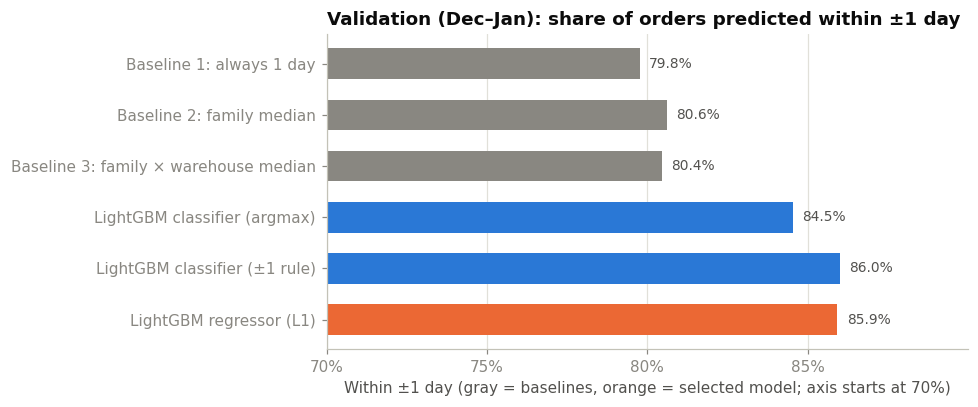

In [21]:
names = list(results)
within = [results[n]["within_1_day"] for n in names]
colors = [MUTED if n.startswith("Baseline") else BLUE for n in names]
winner_name = "LightGBM regressor (L1)" if WINNER == "regressor" else "LightGBM classifier (±1 rule)"
colors[names.index(winner_name)] = ORANGE

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(names[::-1], within[::-1], color=colors[::-1], height=0.6)
for i, v in enumerate(within[::-1]):
    ax.text(v + 0.003, i, f"{v:.1%}", va="center", fontsize=9, color=INK_2)
ax.set_xlim(0.7, max(within) + 0.04)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="x", color=GRID)
ax.grid(axis="y", visible=False)
ax.set_title("Validation (Dec–Jan): share of orders predicted within ±1 day")
ax.set_xlabel("Within ±1 day (gray = baselines, orange = selected model; axis starts at 70%)")
plt.tight_layout()
save_fig(fig, "f1_model_comparison")

**Result: the L1 regressor is selected.** Classifier and regressor tie on the primary metric (86.0% vs 85.9% within ±1 day; the bootstrap puts the gap anywhere from −2.1 to +2.0 points), and the regressor is better on everything else.

| vs. best baseline | Best baseline | Regressor | Change |
|---|---|---|---|
| Within ±1 day | 80.6% (family median) | **85.9%** | +5.3 pts |
| Exact day | 46.9% (always 1) | **52.1%** | +5.2 pts |
| MAE (days) | 0.909 (family median) | **0.776** | −15% |
| Macro-F1 | 0.161 (family × warehouse) | **0.270** | +0.11 |

Put simply: about 1 in 20 orders moves from "more than a day off" to "within a day", and one more order in 20 gets the exact day. The ±1 decision rule does what it was designed to do (+1.5 pts over classifier argmax on ±1), but it costs exact-day accuracy.

### 7.4 Where the selected model is right and wrong: confusion matrix
Rows are what actually happened; columns are what the model predicted. Each row adds up to 100%, so the diagonal is the share of each true bucket predicted exactly right.

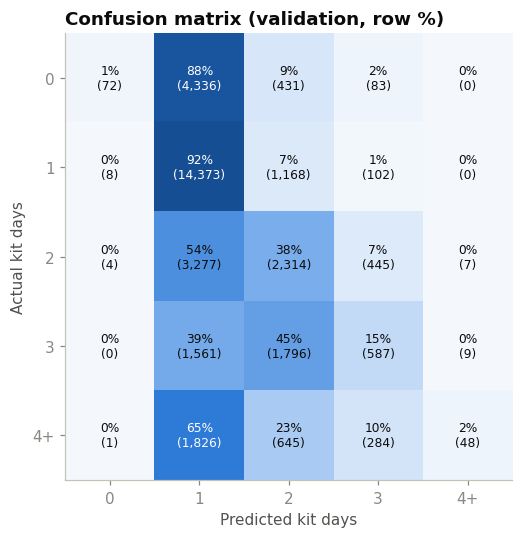

    actual_orders  predicted_orders  recall (row diagonal)
0            4922                85                  0.015
1           15651             25373                  0.918
2            6047              6354                  0.383
3            3953              1501                  0.148
4+           2804                64                  0.017

Macro-F1: 0.270


In [22]:
cm = confusion_matrix(to_bucket(y_val), to_bucket(pred_best), labels=range(5))
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(cm_pct, cmap=blues, vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{cm_pct[i, j]:.0%}\n({cm[i, j]:,})", ha="center", va="center", fontsize=8,
                color="white" if cm_pct[i, j] > 0.55 else INK)
ax.set_xticks(range(5))
ax.set_xticklabels(BUCKETS)
ax.set_yticks(range(5))
ax.set_yticklabels(BUCKETS)
ax.set_xlabel("Predicted kit days")
ax.set_ylabel("Actual kit days")
ax.grid(False)
ax.set_title("Confusion matrix (validation, row %)")
plt.tight_layout()
save_fig(fig, "f2_confusion_matrix")

per_bucket = pd.DataFrame({"actual_orders": cm.sum(axis=1), "predicted_orders": cm.sum(axis=0),
                           "recall (row diagonal)": cm_pct.diagonal().round(3)}, index=BUCKETS)
print(per_bucket.to_string())
print(f"\nMacro-F1: {results[winner_name]['macro_f1']:.3f}")

**Reading the matrix.** The model mostly predicts 1 or 2 days, and that's the main limitation to explain to planners:
- **0-day orders** are almost always predicted as 1 (still within ±1, so they count as hits on the primary metric).
- **4+ orders are rarely predicted as 4+** (1.7%). The L1 objective aims at the *typical* outcome, and nothing in the data reliably says in advance which order will run long. The regressor predicts 3 days for 1,501 orders, so it does lean toward longer predictions where history suggests risk, but it can't commit to 4+.
- This is why the **risk score (7.6)** matters: the day prediction gives the most likely finish, and the risk score says how likely that finish is to slip.

### 7.5 What the model relies on: feature importance
**Gain importance** is how much each feature reduced the model's error, summed over every tree split that used it. It shows what the model *uses*, not proof of cause and effect.

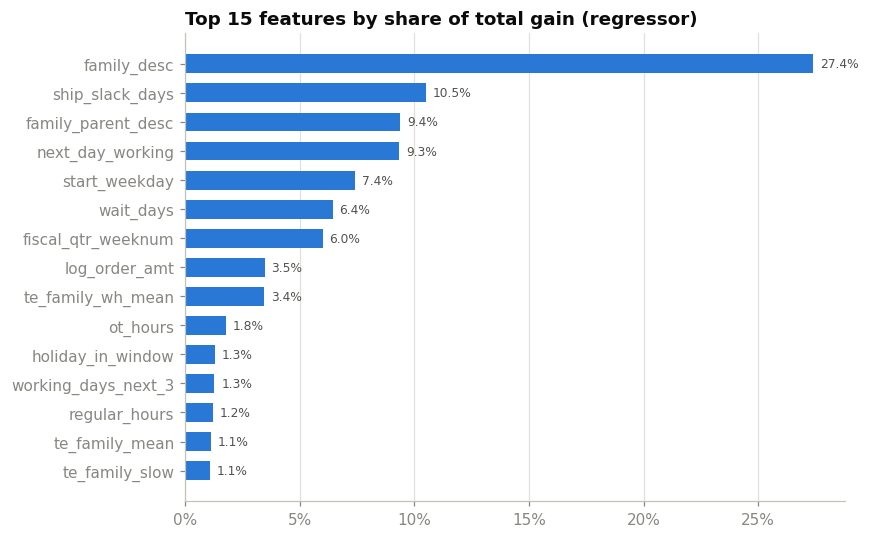

Gain share by feature group:
family history / product    44.5%
schedule & capacity         30.4%
lead times                  17.0%
order size & labor           7.2%
warehouse                    0.9%


In [23]:
best_model, best_cols = (reg_model, REG_COLS) if WINNER == "regressor" else (clf_model, CLF_COLS)
imp = (pd.Series(best_model.booster_.feature_importance("gain"), index=best_cols)
       .sort_values(ascending=False))
imp = imp / imp.sum()
top = imp.head(15)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=BLUE, height=0.65)
for i, v in enumerate(top.values):
    ax.text(v + 0.003, i, f"{v:.1%}", va="center", fontsize=8, color=INK_2)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="x", color=GRID)
ax.grid(axis="y", visible=False)
ax.set_title(f"Top 15 features by share of total gain ({WINNER})")
plt.tight_layout()
save_fig(fig, "f3_feature_importance")

groups = {"family history / product": ["te_", "family", "lob_desc", "buid", "family_order_count"],
          "schedule & capacity": ["weekday", "holiday", "working", "ot_hours", "regular_hours", "is_eoq", "is_idc",
                                  "fiscal"],
          "lead times": ["wait_days", "ship_slack"],
          "order size & labor": ["quantity", "line_qty", "tie_num", "order_amt", "minutes", "cfs", "is_cfi",
                                 "ship_date_placeholder"],
          "warehouse": ["mcid"]}
group_share = {g: imp[[f for f in imp.index if any(k in f for k in keys)]].sum() for g, keys in groups.items()}
print("Gain share by feature group:")
print(pd.Series(group_share).sort_values(ascending=False).map("{:.1%}".format).to_string())

**What drives the predictions.** Product (family, parent family, family history) carries 44.5% of the gain, which matches H1: *which* product it is matters most. Schedule and capacity (next day working, weekday, fiscal week, overtime, holidays) carry 30.4%, which matches H2. Warehouse (`mcid`) carries 0.9%, consistent with the H3 finding that warehouse gaps are mostly product mix.

**One to watch:** `ship_slack_days` (estimated ship date minus kit start) is the second-largest single feature (10.5%). It's in the inference file, so it's usable, *if* `est_ship_date` is set before kitting starts. If Dell revises it after kitting, the feature would leak the outcome; this needs confirming with the data owners (see Assumptions A20).

### 7.6 Probability checks (for the risk flag)
The classifier gives a probability for each bucket. The **risk score** used for planners is **P(4+ days)**: the chance an order runs long. Three checks decide whether that number can be trusted:
1. **Log loss** vs. simply predicting historical class frequencies for everyone. Lower is better; if the model can't beat frequencies, its probabilities carry no information.
2. **Calibration.** Group orders by predicted risk and compare with what actually happened. A well-calibrated model's "20%" orders run long about 20% of the time.
3. **Flag precision and recall.** An order is flagged when its risk is above a threshold. The threshold is set on **November** (the inner split) so that it flags the riskiest **~10% of orders**, a review workload a planning team can realistically handle. It is then *applied unchanged* to Dec–Jan, so the reported precision and recall are honest. (Maximizing F1 on November picked the lowest threshold tried, 0.05, which flags about a third of all orders. That's too many to act on.)

In [24]:
prior_fit = np.bincount(to_bucket(y_fit), minlength=5) / len(y_fit)
ll_model = log_loss(to_bucket(y_val), P_val, labels=range(5))
ll_prior = log_loss(to_bucket(y_val), np.tile(prior_fit, (len(y_val), 1)), labels=range(5))
print(f"Log loss on validation: model {ll_model:.3f} vs class frequencies {ll_prior:.3f} "
      f"({(ll_prior - ll_model) / ll_prior:.1%} better)")

print("\nAverage predicted probability vs actual share, by bucket (validation):")
print(pd.DataFrame({"predicted": P_val.mean(axis=0), "actual": np.bincount(to_bucket(y_val), minlength=5) / len(y_val),
                    "fit-period share": prior_fit}, index=BUCKETS).round(3).to_string())

# Threshold chosen on November with the classifier settings, then frozen
clf_inner = lgb.LGBMClassifier(objective="multiclass", **params_from(CLF_BEST, "clf_trees"))
clf_inner.fit(X_in_fit[CLF_COLS], to_bucket(inner_fit["kit_days"]))
risk_nov = clf_inner.predict_proba(X_in_val[CLF_COLS])[:, 4]
slow_nov = inner_val["kit_days"].to_numpy() >= 4
FLAG_SHARE = 0.10                                          # review budget: riskiest 10% of orders
RISK_THRESHOLD = float(np.round(np.quantile(risk_nov, 1 - FLAG_SHARE), 3))
print(f"\nRisk threshold set on November (flags top {FLAG_SHARE:.0%}): P(4+) ≥ {RISK_THRESHOLD:.3f}")
print(f"  November: precision {precision_score(slow_nov, risk_nov >= RISK_THRESHOLD):.1%}, "
      f"recall {recall_score(slow_nov, risk_nov >= RISK_THRESHOLD):.1%}, base rate {slow_nov.mean():.1%}")

risk_val = P_val[:, 4]
slow_val = y_val.to_numpy() >= 4
flag_rows = []
for t in sorted({0.05, 0.10, 0.20, 0.30, RISK_THRESHOLD}):
    flag = risk_val >= t
    precision = precision_score(slow_val, flag, zero_division=0)
    flag_rows.append({"threshold": t, "orders_flagged": flag.mean(), "precision": precision,
                      "recall": recall_score(slow_val, flag, zero_division=0),
                      "lift_vs_random": precision / slow_val.mean()})
flag_table = pd.DataFrame(flag_rows).set_index("threshold")
print(f"\nValidation base rate of 4+ orders: {slow_val.mean():.1%}  (lift = precision ÷ base rate)")
print(flag_table.assign(**{c: flag_table[c].map("{:.1%}".format) for c in ["orders_flagged", "precision", "recall"]},
                        lift_vs_random=flag_table["lift_vs_random"].map("{:.1f}×".format)).to_string())

month = val_df["kit_start"].dt.strftime("%Y-%m").values
print("\nMean predicted P(4+) vs actual 4+ share by month:")
print(pd.DataFrame({"predicted": pd.Series(risk_val).groupby(month).mean(),
                    "actual": pd.Series(slow_val).groupby(month).mean()}).round(3).to_string())

Log loss on validation: model 1.260 vs class frequencies 1.438 (12.4% better)

Average predicted probability vs actual share, by bucket (validation):
    predicted  actual  fit-period share
0       0.194   0.147             0.209
1       0.487   0.469             0.495
2       0.177   0.181             0.167
3       0.090   0.118             0.083
4+      0.052   0.084             0.046



Risk threshold set on November (flags top 10%): P(4+) ≥ 0.096
  November: precision 16.6%, recall 22.5%, base rate 7.3%

Validation base rate of 4+ orders: 8.4%  (lift = precision ÷ base rate)
          orders_flagged precision recall lift_vs_random
threshold                                               
0.050              31.8%     17.4%  65.8%           2.1×
0.096              12.5%     25.2%  37.3%           3.0×
0.100              11.5%     26.3%  36.1%           3.1×
0.200               3.2%     34.0%  13.1%           4.1×
0.300               1.2%     36.3%   5.2%           4.3×

Mean predicted P(4+) vs actual 4+ share by month:
         predicted  actual
2025-12      0.050   0.089
2026-01      0.053   0.079


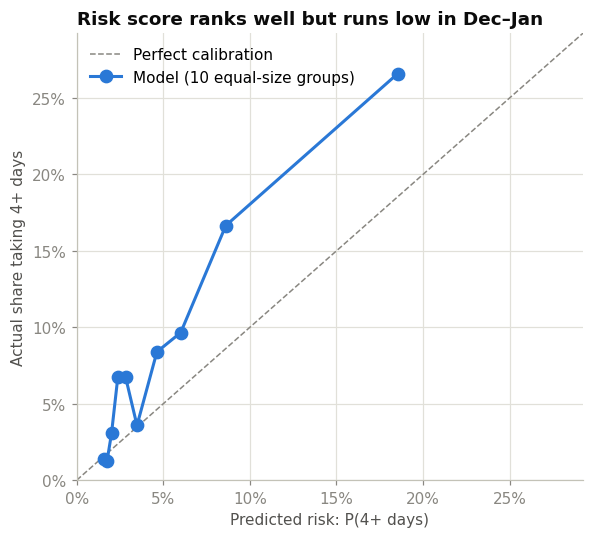

                  predicted  actual  orders
bin                                        
(0.0115, 0.0166]      0.016   0.014    3338
(0.0166, 0.0186]      0.018   0.013    3338
(0.0186, 0.0217]      0.020   0.031    3338
(0.0217, 0.0257]      0.024   0.068    3337
(0.0257, 0.0308]      0.028   0.067    3338
(0.0308, 0.0402]      0.035   0.036    3350
(0.0402, 0.0523]      0.046   0.084    3325
(0.0523, 0.0688]      0.060   0.097    3356
(0.0688, 0.107]       0.086   0.167    3320
(0.107, 0.656]        0.185   0.266    3337


In [25]:
calib = pd.DataFrame({"risk": risk_val, "slow": slow_val})
calib["bin"] = pd.qcut(calib["risk"], 10, duplicates="drop")
calib_tbl = calib.groupby("bin", observed=True).agg(predicted=("risk", "mean"), actual=("slow", "mean"),
                                                    orders=("slow", "size"))

fig, ax = plt.subplots(figsize=(5.5, 5))
lim = max(calib_tbl["predicted"].max(), calib_tbl["actual"].max()) * 1.1
ax.plot([0, lim], [0, lim], color=MUTED, linewidth=1, linestyle="--", label="Perfect calibration")
ax.plot(calib_tbl["predicted"], calib_tbl["actual"], color=BLUE, linewidth=2, marker="o", markersize=8,
        label="Model (10 equal-size groups)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="x", color=GRID)
ax.set_xlabel("Predicted risk: P(4+ days)")
ax.set_ylabel("Actual share taking 4+ days")
ax.set_title("Risk score ranks well but runs low in Dec–Jan")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
save_fig(fig, "f4_calibration")
print(calib_tbl.round(3).to_string())

**Probability checks: results.**
- **The probabilities carry real information:** log loss is 12.4% better than predicting historical class frequencies (1.260 vs 1.438).
- **Ranking is good; the level runs low.** Orders in the top tenth of risk ran long 26.6% of the time, vs 1.4% in the bottom tenth. But nearly every point sits above the diagonal: the model predicted a 5.2% average chance of 4+ days when the true rate was 8.4%. The gap holds in both months (Dec 5.0% vs 8.9%, Jan 5.3% vs 7.9%), not just the holidays. The fitting period (Mar–Nov) had fewer slow orders (4.6%) than Dec–Jan, so the model learned a lower base rate. The final model is retrained through January, which partly corrects this.
- **Flag performance (threshold set on November, applied unchanged):** flagging P(4+) ≥ 0.096 marks 12.5% of Dec–Jan orders. A quarter of flagged orders (25.2%) really ran 4+ days, **3.0× the rate of a random pick**, and the flag catches 37.3% of all slow orders.
- **How to use it:** treat the risk score as a **ranking** ("these are the riskiest orders this week"), not a literal percentage. Re-check calibration on recent months before quoting the numbers directly.

### 7.7 Error analysis: what the data can't explain
The goal here is evidence for the recommendation, not model tweaks. Three questions:
1. **How much error remains?** And is it the slow orders that drive it?
2. **Where do misses cluster?** If misses bunch up in particular weeks and families (like the shortage bursts in 4.2), something time- and product-specific is missing from the data.
3. **How different are "identical" orders?** Group validation orders that share family, warehouse *and* start date. Every feature about product, place and schedule is the same within a group, so any spread inside it comes from something the data doesn't record, such as a missing part, a full staging area, or a staffing gap. Predicting every order with its **own group's actual median** (a cheat no real model could use) sets a **ceiling** on what this data can achieve.

A **miss** is a prediction more than 1 day off.

In [26]:
ea = val_df[["family_desc", "mcid", "kit_start", "kit_days"]].copy()
ea["pred"] = pred_best
ea["err"] = ea["kit_days"] - ea["pred"]
ea["abs_err"] = ea["err"].abs()
ea["miss"] = ea["abs_err"] >= 2
ea["slow"] = ea["kit_days"] >= 4

print("1) Remaining error")
print(f"   MAE {ea['abs_err'].mean():.3f} days; misses (off by 2+ days): {ea['miss'].mean():.1%} of orders")
print(f"   Orders that took 4+ days: {ea['slow'].mean():.1%} of orders but {ea.loc[ea['slow'], 'abs_err'].sum() / ea['abs_err'].sum():.1%} "
      f"of total absolute error")
print(f"   Misses where the order took LONGER than predicted: {(ea.loc[ea['miss'], 'err'] > 0).mean():.1%}")

# 2) Clustering by family-week, relative to the plant that week
ea["week"] = ea["kit_start"].dt.to_period("W").dt.start_time
plant_miss = ea.groupby("week")["miss"].mean()
fw = ea.groupby(["family_desc", "week"]).agg(orders=("miss", "size"), misses=("miss", "sum"),
                                             miss_rate=("miss", "mean")).reset_index()
fw = fw[fw["orders"] >= 20]
fw["excess"] = fw["miss_rate"] - fw["week"].map(plant_miss)
hot = fw[fw["excess"] > 0.25]
print("\n2) Where misses cluster")
print(f"   Family-weeks (20+ orders): {len(fw)}; 'hot' ones (miss rate > plant that week + 25 pts): {len(hot)} "
      f"({len(hot) / len(fw):.1%})")
print(f"   Those hot family-weeks hold {hot['orders'].sum() / len(ea):.1%} of validation orders "
      f"but {hot['misses'].sum() / ea['miss'].sum():.1%} of all misses")
top_fam = ea.groupby("family_desc")["miss"].sum().sort_values(ascending=False)
print(f"   Top 10 families (of {ea['family_desc'].nunique()}) account for {top_fam.head(10).sum() / ea['miss'].sum():.1%} of misses")
print("   Miss rate by warehouse: " + ", ".join(f"{k} {v:.1%}" for k, v in
                                               ea.groupby("mcid")["miss"].mean().sort_values(ascending=False).items()))

# 3) Spread among identical-looking orders
grp = ea.groupby(["family_desc", "mcid", "kit_start"])["kit_days"]
ea["grp_size"] = grp.transform("size")
ea["grp_range"] = grp.transform("max") - grp.transform("min")
ea["grp_median"] = grp.transform("median")
same = ea[ea["grp_size"] >= 5]
within_var = same.groupby(["family_desc", "mcid", "kit_start"])["kit_days"].var(ddof=0).mean()
print("\n3) Spread among identical-looking orders (same family + warehouse + start date, groups of 5+)")
print(f"   Covers {len(same):,} validation orders ({len(same) / len(ea):.1%}) in "
      f"{same.groupby(['family_desc', 'mcid', 'kit_start']).ngroups:,} groups")
print(f"   Orders in groups whose kit days span 3+ days: {(same['grp_range'] >= 3).mean():.1%}")
print(f"   Share of kit-day variance that is WITHIN groups: {within_var / same['kit_days'].var(ddof=0):.1%}")
ceiling = score(same["kit_days"], same["grp_median"])["within_1_day"]
model_same = score(same["kit_days"], same["pred"])["within_1_day"]
print(f"   ±1-day accuracy on these orders: model {model_same:.1%} | ceiling using the group's own actual median {ceiling:.1%}")

1) Remaining error
   MAE 0.776 days; misses (off by 2+ days): 14.1% of orders
   Orders that took 4+ days: 8.4% of orders but 40.2% of total absolute error
   Misses where the order took LONGER than predicted: 86.7%

2) Where misses cluster
   Family-weeks (20+ orders): 386; 'hot' ones (miss rate > plant that week + 25 pts): 40 (10.4%)
   Those hot family-weeks hold 9.2% of validation orders but 41.8% of all misses
   Top 10 families (of 246) account for 47.6% of misses
   Miss rate by warehouse: 3JU 23.4%, 3JHF 22.1%, KL3 16.0%, 3JL3 10.6%, KHO 10.2%, KL1 9.9%, RCH 9.8%, KLJ 0.0%

3) Spread among identical-looking orders (same family + warehouse + start date, groups of 5+)
   Covers 27,606 validation orders (82.7%) in 1,563 groups
   Orders in groups whose kit days span 3+ days: 22.0%
   Share of kit-day variance that is WITHIN groups: 33.2%
   ±1-day accuracy on these orders: model 86.0% | ceiling using the group's own actual median 93.4%


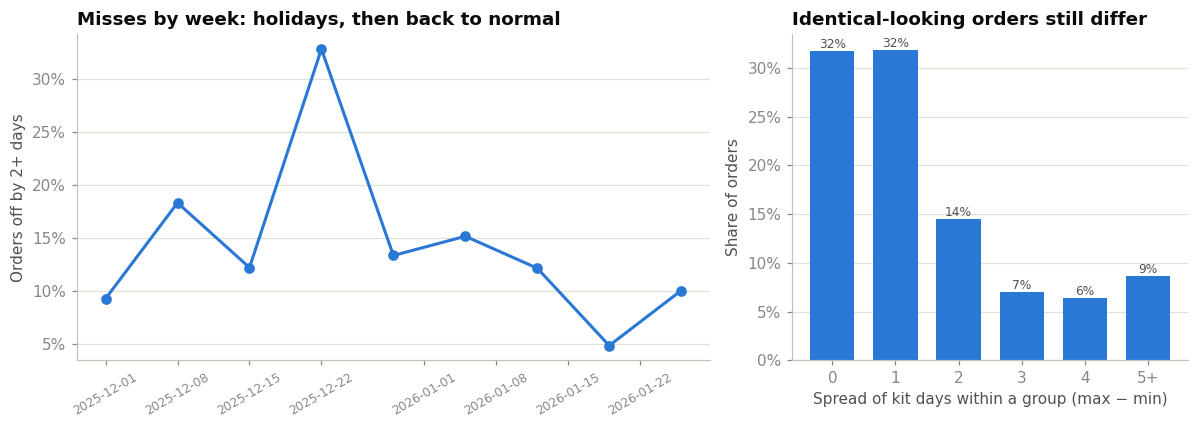

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.6, 1]})
ax1.plot(plant_miss.index, plant_miss.values, color=BLUE, linewidth=2, marker="o", markersize=6)
ax1.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax1.set_title("Misses by week: holidays, then back to normal")
ax1.set_ylabel("Orders off by 2+ days")
ax1.tick_params(axis="x", labelsize=8)
for label in ax1.get_xticklabels():
    label.set_rotation(30)

range_counts = same["grp_range"].clip(upper=5).value_counts(normalize=True).sort_index()
ax2.bar([str(int(r)) if r < 5 else "5+" for r in range_counts.index], range_counts.values, color=BLUE, width=0.7)
for i, v in enumerate(range_counts.values):
    ax2.text(i, v, f"{v:.0%}", ha="center", va="bottom", fontsize=8, color=INK_2)
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax2.set_title("Identical-looking orders still differ")
ax2.set_xlabel("Spread of kit days within a group (max − min)")
ax2.set_ylabel("Share of orders")
plt.tight_layout()
save_fig(fig, "f5_error_analysis")

**Error analysis: evidence that key information is missing.**
1. **The tail drives the error.** Orders that took 4+ days are 8.4% of validation orders but cause **40.2% of all absolute error**. And 86.7% of misses are orders that took *longer* than predicted: the model is rarely surprised by speed, often by delay.
2. **Misses cluster by product and week.** 40 family-weeks, holding 9.2% of orders, contain **41.8% of all misses**. The top 10 of 246 families account for 47.6% of misses. The same pattern appeared in exploration: slowdowns hit one family at a time, as a part shortage would. The model can't anticipate them because nothing in the data records part availability.
3. **Identical-looking orders still differ.** Among orders with the same family, warehouse *and* start date (82.7% of validation orders), a third of the variance in kit days (33.2%) is *within* those groups, and 22.0% of orders sit in a group whose kit days span 3+ days. Every recorded feature is identical inside a group, so those differences come from something not in the data.
4. **A ceiling on what this data can do.** Even if you somehow knew each group's *actual* median outcome, a cheat that includes whatever went wrong that day, ±1-day accuracy would be 93.4%, vs the model's 86.0% on the same orders. The 7.4-point gap is the value of knowing day-specific conditions (a shortage in effect, a congested warehouse). The remaining 6.6% can't be reached even then, because it comes from order-level differences such as which specific parts an order needs.

**Implication:** better algorithms on the same columns have limited headroom. The biggest gains need **new data**: part availability / shortage flags per order and daily warehouse capacity or occupancy. That is the headline recommendation for the README.

### 7.8 Retrain on all training data
The validation run fit on Mar–Nov. The final models refit on **everything through Jan 31**, with the same settings and tree counts, so they learn from the most recent two months, including the families first seen in December and January. Family-history encodings and category lists are rebuilt on the full training set. Both models are kept: the **selected model** produces the predicted days, and the **classifier** produces the risk score.

In [28]:
X_all = build_features(train_clean, train_clean, is_fit=True)
y_all = train_clean["kit_days"]
final_reg = lgb.LGBMRegressor(objective="regression_l1", **params_from(REG_BEST, "reg_trees"))
final_reg.fit(X_all[REG_COLS], train_clean["kit_days_capped"])
final_clf = lgb.LGBMClassifier(objective="multiclass", **params_from(CLF_BEST, "clf_trees"))
final_clf.fit(X_all[CLF_COLS], to_bucket(y_all))
tail_all = train_clean.loc[train_clean["kit_days"] >= 4, "kit_days"].to_numpy()
print(f"Final models trained on {len(X_all):,} rows "
      f"({train_clean['kit_start'].min().date()} → {train_clean['kit_start'].max().date()}); predictions come from the {WINNER}")

Final models trained on 177,727 rows (2025-03-10 → 2026-01-31); predictions come from the regressor


## 8. Inference predictions

Apply the final models to the 12,069 inference orders:
1. Build features with every learned mapping (family histories, category lists) fit on **all training data**. Inference targets are never used, since they don't exist.
2. **Predicted days** come from the selected model; the **risk score** P(4+ days) comes from the classifier.
3. `kit_end = kit_start + predicted days`, stored as `datetime64[D]` in the original row order (Decision 6).
4. Assert the output is complete and consistent before saving, then reload the file and check it round-trips exactly.

In [29]:
X_inf = build_features(train_clean, inference_clean, is_fit=False)
assert list(X_inf.columns) == FEATURES

if WINNER == "regressor":
    inf_days = np.clip(np.rint(final_reg.predict(X_inf[REG_COLS])), 0, None).astype(int)
else:
    inf_days = within1_decision(final_clf.predict_proba(X_inf[CLF_COLS]), tail_all)
inf_risk = final_clf.predict_proba(X_inf[CLF_COLS])[:, 4]

kit_start_d = inference_clean["kit_start"].to_numpy().astype("datetime64[D]")
kit_end_pred = kit_start_d + inf_days.astype("timedelta64[D]")

# Output checks (Decision 6)
assert kit_end_pred.dtype == np.dtype("datetime64[D]")
assert len(kit_end_pred) == len(inference) == 12_069
assert not np.isnat(kit_end_pred).any()
assert (kit_end_pred >= kit_start_d).all()
assert (inference_clean["sales_order_id"].to_numpy() == inference["sales_order_id"].to_numpy()).all()
assert (kit_start_d == inference["kit_start"].to_numpy().astype("datetime64[D]")).all()

PRED_PATH = Path("Zakir_Patwa_DS_Case_Predictions_2026.npy")
np.save(PRED_PATH, kit_end_pred)
reloaded = np.load(PRED_PATH)                 # plain np.load, no allow_pickle needed
assert reloaded.dtype == np.dtype("datetime64[D]") and (reloaded == kit_end_pred).all()
print(f"Saved {PRED_PATH} → {len(reloaded):,} dates, dtype {reloaded.dtype}, "
      f"{reloaded.min()} to {reloaded.max()}. All checks passed ✓")

Saved Zakir_Patwa_DS_Case_Predictions_2026.npy → 12,069 dates, dtype datetime64[D], 2026-02-04 to 2026-03-09. All checks passed ✓


### 8.1 Planner CSV
A companion file planners can open in Excel: one row per inference order, same order as `inference.parquet`, with the predicted finish, the risk score, and the risk flag (P(4+) at or above the threshold from 7.6). It contains order IDs from the source data, so it is **not committed** to the repository.

In [30]:
planner = pd.DataFrame({
    "sales_order_id": inference_clean["sales_order_id"].to_numpy(),
    "family_desc": inference_clean["family_desc"].to_numpy(),
    "mcid": inference_clean["mcid"].to_numpy(),
    "kit_start": kit_start_d,
    "predicted_kit_end": kit_end_pred,
    "predicted_kit_days": inf_days,
    "risk_4plus_days": inf_risk.round(4),
    "high_risk_flag": (inf_risk >= RISK_THRESHOLD).astype(int),
})
CSV_PATH = Path("Zakir_Patwa_DS_Case_Predictions_2026.csv")
planner.to_csv(CSV_PATH, index=False)
assert len(pd.read_csv(CSV_PATH)) == 12_069
print(f"Saved {CSV_PATH} ({len(planner):,} rows)")
planner.head()

Saved Zakir_Patwa_DS_Case_Predictions_2026.csv (12,069 rows)


,sales_order_id,family_desc,mcid,kit_start,predicted_kit_end,predicted_kit_days,risk_4plus_days,high_risk_flag
0,1026073335,HMFRUNTS IXX,KHO,2026-02-13,2026-02-14,1,0.0464,0
1,1027826085,UFQT AJWIJ UJ,3JU,2026-02-10,2026-02-11,1,0.0447,0
2,1029739753,HTSHMT UJ,KHO,2026-02-26,2026-02-27,1,0.0759,0
3,1030454098,HQJJP-K710,KHO,2026-02-12,2026-02-13,1,0.1090,1
4,1029526599,UFYWFX TJRW,3JU,2026-02-11,2026-02-12,1,0.0310,0


### 8.2 Sanity checks on the predictions
Inference has no answers to score against, so these checks confirm the predictions behave sensibly: a distribution similar to validation, longer predictions before the known closure on 2026-02-06/07, and a flag rate in line with the ~10% target.

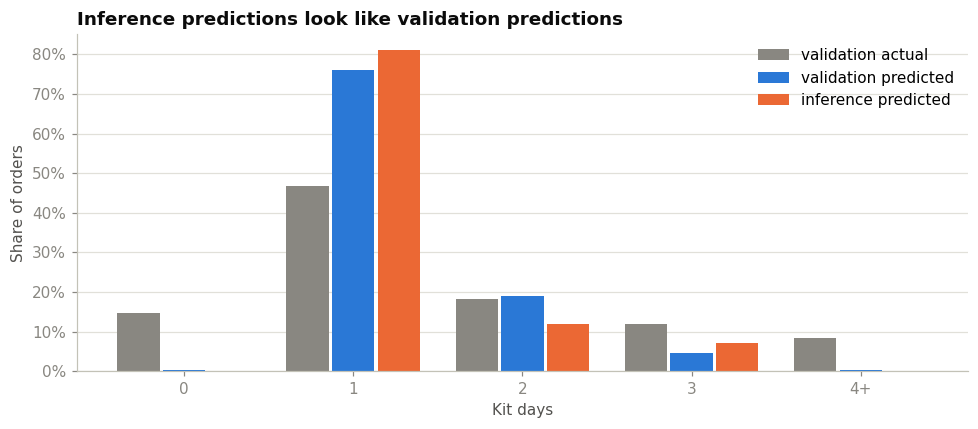

    validation actual  validation predicted  inference predicted
0               0.147                 0.003                0.000
1               0.469                 0.760                0.811
2               0.181                 0.190                0.119
3               0.118                 0.045                0.070
4+              0.084                 0.002                0.000

Mean predicted days: all 1.26; next day closed 2.48 (1,442 orders); next day working 1.09
Mean predicted days by start weekday: Monday 1.07, Tuesday 1.02, Wednesday 1.07, Thursday 1.72, Friday 1.11, Saturday 2.21, Sunday 1.57
High-risk flag rate: 19.4% of inference orders (mean risk 7.0%)
Unseen families in inference: 10 rows


In [31]:
val_pred_share = pd.Series(to_bucket(pred_best)).value_counts(normalize=True).reindex(range(5), fill_value=0)
inf_pred_share = pd.Series(to_bucket(inf_days)).value_counts(normalize=True).reindex(range(5), fill_value=0)
val_true_share = pd.Series(to_bucket(y_val)).value_counts(normalize=True).reindex(range(5), fill_value=0)
dist = pd.DataFrame({"validation actual": val_true_share, "validation predicted": val_pred_share,
                     "inference predicted": inf_pred_share})
dist.index = BUCKETS

fig, ax = plt.subplots()
x = np.arange(5)
for i, (col, color) in enumerate(zip(dist.columns, [MUTED, BLUE, ORANGE])):
    ax.bar(x + (i - 1) * 0.27, dist[col], width=0.25, color=color, label=col)
ax.set_xticks(x)
ax.set_xticklabels(BUCKETS)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Kit days")
ax.set_ylabel("Share of orders")
ax.set_title("Inference predictions look like validation predictions")
ax.legend(frameon=False)
plt.tight_layout()
save_fig(fig, "g1_prediction_distribution")
print(dist.round(3).to_string())

nxt = X_inf["next_day_working"]
print(f"\nMean predicted days: all {inf_days.mean():.2f}; next day closed {inf_days[nxt.eq(0)].mean():.2f} "
      f"({nxt.eq(0).sum():,} orders); next day working {inf_days[nxt.eq(1)].mean():.2f}")
print("Mean predicted days by start weekday: " + ", ".join(
    f"{d} {v:.2f}" for d, v in pd.Series(inf_days).groupby(inference_clean['kit_start'].dt.day_name().values).mean()
    .reindex(weekday_order).dropna().items()))
print(f"High-risk flag rate: {(inf_risk >= RISK_THRESHOLD).mean():.1%} of inference orders "
      f"(mean risk {inf_risk.mean():.1%})")
print(f"Unseen families in inference: {X_inf['family_desc'].isna().sum()} rows")

**Result.** The predictions behave as expected:
- **12,069 dates** from 2026-02-04 to 2026-03-09, in the original row order, with every check passing.
- **The closure shows up.** The 1,442 orders whose next day is a closed day (2026-02-06/07, and Sundays) are predicted at 2.48 days on average vs 1.09 otherwise. Thursday starts (1.72) are high because Thursday 2026-02-05 runs into the Feb 6–7 closure.
- **Like the validation predictions, the model concentrates on 1–2 days** (81% predicted 1 day). It rarely predicts 0 or 4+, for the reasons in 7.4. Expect real outcomes to spread more widely than the predictions.
- **Flag rate is 19.4%, not ~10%.** The final classifier was retrained through January, when slow orders were more common (8.4% vs 4.6% earlier), so its risk scores run higher (mean 7.0%). The threshold is kept fixed because its precision and recall were validated at that value. A team that can only review ~10% of orders should sort by `risk_4plus_days` and take the top of the list (see Decisions for review).